In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 0 — RUN THIS FIRST EVERY SESSION (Mount Google Drive)
# ═══════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
from pathlib import Path

# ── Your project lives here permanently ──────────────────────
DRIVE_PROJECT = Path("/content/drive/MyDrive/Capstone_MentalHealth")
DRIVE_DATA    = DRIVE_PROJECT / "data"
DRIVE_MODELS  = DRIVE_PROJECT / "models"
DRIVE_PLOTS   = DRIVE_PROJECT / "plots"

# Create folders if first time
for folder in [DRIVE_PROJECT, DRIVE_DATA, DRIVE_MODELS, DRIVE_PLOTS]:
    folder.mkdir(parents=True, exist_ok=True)

# ── Local working paths (fast, in-session) ───────────────────
LOCAL_DATA   = Path("/content/data")
LOCAL_MODELS = Path("/content/models")
LOCAL_DATA.mkdir(exist_ok=True)
LOCAL_MODELS.mkdir(exist_ok=True)

# ── Copy files FROM Drive to local (restores previous work) ──
def restore_from_drive():
    restored = []
    for src in list(DRIVE_DATA.glob("*.csv")) + \
               list(DRIVE_MODELS.glob("*.pkl")):
        dest_dir = LOCAL_DATA if src.suffix == ".csv" else LOCAL_MODELS
        dest = dest_dir / src.name
        if not dest.exists():
            shutil.copy2(src, dest)
            restored.append(src.name)
    if restored:
        print(f"✅ Restored from Drive: {restored}")
    else:
        print("✅ Drive mounted. No new files to restore.")

restore_from_drive()

print(f"\n📁 Drive project folder: {DRIVE_PROJECT}")
print(f"   data/    → {list(DRIVE_DATA.glob('*'))}")
print(f"   models/  → {list(DRIVE_MODELS.glob('*'))}")
print(f"   plots/   → {list(DRIVE_PLOTS.glob('*'))}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted. No new files to restore.

📁 Drive project folder: /content/drive/MyDrive/Capstone_MentalHealth
   data/    → []
   models/  → []
   plots/   → []


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
sns.set_theme(style="whitegrid", palette="muted")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── CELL 1: Load All 7 Files ─────────────────────────────────
DATA = Path("/content/data/")

assessments       = pd.read_csv(DATA / "assessments.csv")
courses           = pd.read_csv(DATA / "courses.csv")
studentAssessment = pd.read_csv(DATA / "studentAssessment.csv")
studentInfo       = pd.read_csv(DATA / "studentInfo.csv")
studentReg        = pd.read_csv(DATA / "studentRegistration.csv")
studentVle        = pd.read_csv(DATA / "studentVle.csv")
vle               = pd.read_csv(DATA / "vle.csv")

print("=" * 55)
print("✅ ALL FILES LOADED")
print("=" * 55)
for name, df in [("assessments",       assessments),
                  ("courses",           courses),
                  ("studentAssessment", studentAssessment),
                  ("studentInfo",       studentInfo),
                  ("studentReg",        studentReg),
                  ("studentVle",        studentVle),
                  ("vle",               vle)]:
    print(f"  {name:<22} → {df.shape[0]:>8,} rows  |  cols: {list(df.columns)}")

✅ ALL FILES LOADED
  assessments            →      206 rows  |  cols: ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']
  courses                →       22 rows  |  cols: ['code_module', 'code_presentation', 'module_presentation_length']
  studentAssessment      →  173,912 rows  |  cols: ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']
  studentInfo            →   32,593 rows  |  cols: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']
  studentReg             →   32,593 rows  |  cols: ['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']
  studentVle             → 10,655,280 rows  |  cols: ['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']
  vle                    →    6,364 rows  |  cols: ['id_site', 'code_module'

In [ ]:
# ── CELL 2: FIX DTYPES — Convert all date/numeric cols safely ─
print("\n⚙️  Fixing column dtypes...")

# studentRegistration — date columns are numeric (days relative to course start)
studentReg['date_registration']   = pd.to_numeric(studentReg['date_registration'],   errors='coerce')
studentReg['date_unregistration'] = pd.to_numeric(studentReg['date_unregistration'], errors='coerce')

# studentAssessment — score and date columns
studentAssessment['score']          = pd.to_numeric(studentAssessment['score'],          errors='coerce')
studentAssessment['date_submitted'] = pd.to_numeric(studentAssessment['date_submitted'], errors='coerce')
studentAssessment['is_banked']      = pd.to_numeric(studentAssessment['is_banked'],      errors='coerce').fillna(0)

# studentVle — clicks and date
studentVle['sum_click'] = pd.to_numeric(studentVle['sum_click'], errors='coerce').fillna(0)
studentVle['date']      = pd.to_numeric(studentVle['date'],      errors='coerce')

# assessments metadata
assessments['weight'] = pd.to_numeric(assessments['weight'], errors='coerce').fillna(0)
assessments['date']   = pd.to_numeric(assessments['date'],   errors='coerce')

# studentInfo numeric columns
studentInfo['num_of_prev_attempts'] = pd.to_numeric(studentInfo['num_of_prev_attempts'], errors='coerce').fillna(0)
studentInfo['studied_credits']      = pd.to_numeric(studentInfo['studied_credits'],      errors='coerce').fillna(0)

print("✅ Dtypes fixed\n")
print("studentReg dtypes:")
print(studentReg.dtypes)
print("\nstudentAssessment dtypes:")
print(studentAssessment.dtypes)


⚙️  Fixing column dtypes...
✅ Dtypes fixed

studentReg dtypes:
code_module             object
code_presentation       object
id_student               int64
date_registration      float64
date_unregistration    float64
dtype: object

studentAssessment dtypes:
id_assessment       int64
id_student          int64
date_submitted      int64
is_banked           int64
score             float64
dtype: object


In [ ]:
# ── CELL 3: Create At-Risk Labels ────────────────────────────
risk_map = {
    'Withdrawn':   2,
    'Fail':        1,
    'Pass':        0,
    'Distinction': 0
}
studentInfo['risk_level'] = studentInfo['final_result'].map(risk_map)
studentInfo['is_at_risk'] = (studentInfo['risk_level'] >= 1).astype(int)

print("\n=== AT-RISK LABEL DISTRIBUTION ===")
print(studentInfo['is_at_risk'].value_counts().rename({0: 'Not At-Risk', 1: 'At-Risk'}))
print(f"At-Risk Rate: {studentInfo['is_at_risk'].mean()*100:.1f}%")


=== AT-RISK LABEL DISTRIBUTION ===
is_at_risk
At-Risk        17208
Not At-Risk    15385
Name: count, dtype: int64
At-Risk Rate: 52.8%


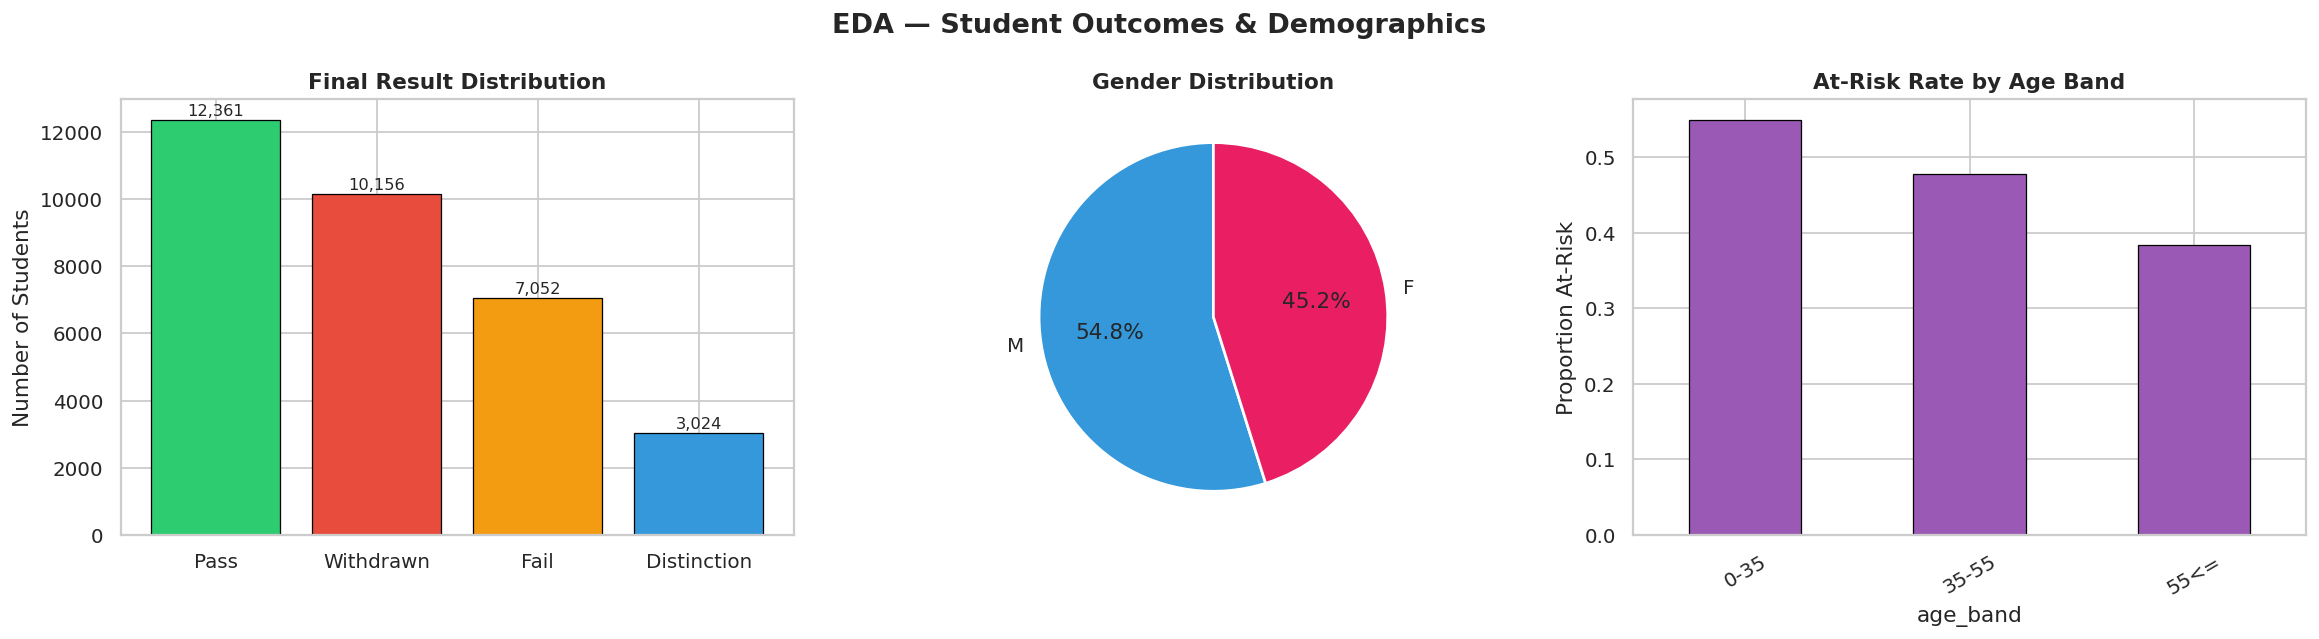

✅ Saved: plot1_outcomes_demographics.png


In [ ]:
# ── CELL 4: PLOT 1 — Outcomes & Demographics ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("EDA — Student Outcomes & Demographics", fontsize=15, fontweight='bold')

colors = {'Withdrawn': '#e74c3c', 'Fail': '#f39c12',
          'Pass': '#2ecc71', 'Distinction': '#3498db'}
vc = studentInfo['final_result'].value_counts()
bars = axes[0].bar(vc.index, vc.values,
                   color=[colors.get(x, 'gray') for x in vc.index],
                   edgecolor='black', linewidth=0.7)
axes[0].set_title('Final Result Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Students')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=9)

studentInfo['gender'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#3498db', '#e91e63'], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Gender Distribution', fontweight='bold')
axes[1].set_ylabel('')

age_risk = (studentInfo.groupby('age_band')['is_at_risk']
            .mean().sort_values(ascending=False))
age_risk.plot(kind='bar', ax=axes[2], color='#9b59b6',
              edgecolor='black', linewidth=0.7)
axes[2].set_title('At-Risk Rate by Age Band', fontweight='bold')
axes[2].set_ylabel('Proportion At-Risk')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('plot1_outcomes_demographics.png', bbox_inches='tight')
plt.show()
print("✅ Saved: plot1_outcomes_demographics.png")

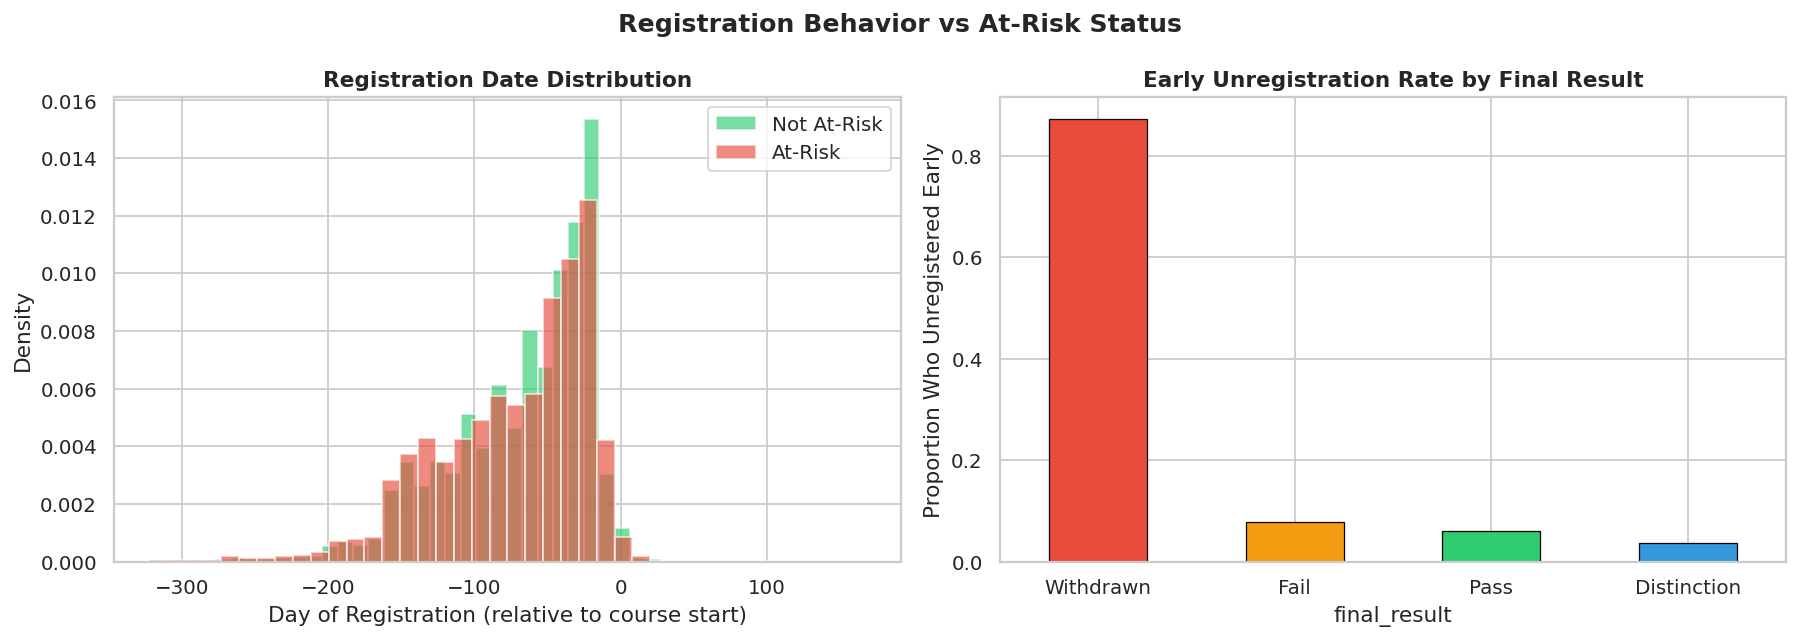

✅ Saved: plot2_registration_patterns.png


In [ ]:
# ── CELL 5: PLOT 2 — Registration Patterns ───────────────────
studentReg['unregistered_early'] = studentReg['date_unregistration'].notna().astype(int)

reg_merged = studentReg.merge(
    studentInfo[['id_student', 'is_at_risk', 'final_result']],
    on='id_student', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Registration Behavior vs At-Risk Status",
             fontsize=14, fontweight='bold')

for risk_val, label, color in [(0, 'Not At-Risk', '#2ecc71'),
                                (1, 'At-Risk',    '#e74c3c')]:
    subset = reg_merged[reg_merged['is_at_risk'] == risk_val]['date_registration'].dropna()
    axes[0].hist(subset, bins=40, alpha=0.65, label=label,
                 color=color, density=True)
axes[0].set_title('Registration Date Distribution', fontweight='bold')
axes[0].set_xlabel('Day of Registration (relative to course start)')
axes[0].set_ylabel('Density')
axes[0].legend()

unreg_rate = (reg_merged.groupby('final_result')['unregistered_early']
              .mean().sort_values(ascending=False))
unreg_rate.plot(kind='bar', ax=axes[1],
                color=['#e74c3c','#f39c12','#2ecc71','#3498db'],
                edgecolor='black', linewidth=0.7)
axes[1].set_title('Early Unregistration Rate by Final Result', fontweight='bold')
axes[1].set_ylabel('Proportion Who Unregistered Early')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('plot2_registration_patterns.png', bbox_inches='tight')
plt.show()
print("✅ Saved: plot2_registration_patterns.png")

In [ ]:
# ── CELL 6: VLE Engagement Features ──────────────────────────
print("⏳ Building VLE engagement features...")

vle_agg = studentVle.groupby('id_student').agg(
    total_clicks      = ('sum_click', 'sum'),
    active_days       = ('date',      'nunique'),
    avg_daily_clicks  = ('sum_click', 'mean'),
    max_daily_clicks  = ('sum_click', 'max'),
    first_activity    = ('date',      'min'),
    last_activity     = ('date',      'max')
).reset_index()

vle_agg['engagement_span'] = vle_agg['last_activity'] - vle_agg['first_activity']

# Early vs Late semester split
median_date = studentVle['date'].median()
early = (studentVle[studentVle['date'] <= median_date]
         .groupby('id_student')['sum_click'].sum()
         .rename('early_clicks'))
late  = (studentVle[studentVle['date'] >  median_date]
         .groupby('id_student')['sum_click'].sum()
         .rename('late_clicks'))

vle_agg = vle_agg.merge(early, on='id_student', how='left')
vle_agg = vle_agg.merge(late,  on='id_student', how='left')
vle_agg[['early_clicks', 'late_clicks']] = vle_agg[['early_clicks', 'late_clicks']].fillna(0)

# Engagement decline score
vle_agg['engagement_decline'] = (
    (vle_agg['early_clicks'] - vle_agg['late_clicks']) /
    (vle_agg['early_clicks'] + 1)
).clip(-2, 2)

print(f"✅ VLE features: {len(vle_agg):,} students")

⏳ Building VLE engagement features...
✅ VLE features: 26,074 students


In [ ]:
# ── CELL 7: Assessment Features (FIXED) ──────────────────────
print("⏳ Building assessment features...")

# Merge student scores with assessment metadata
assess_full = studentAssessment.merge(
    assessments[['id_assessment', 'assessment_type', 'weight']],
    on='id_assessment', how='left'
)

# Basic aggregations — all numeric, no string mean
assess_agg = assess_full.groupby('id_student').agg(
    mean_score      = ('score',       'mean'),
    min_score       = ('score',       'min'),
    max_score       = ('score',       'max'),
    score_std       = ('score',       'std'),
    num_assessments = ('score',       'count'),
    num_unsubmitted = ('is_banked',   lambda x: (x == 0).sum()),
    num_late        = ('date_submitted', lambda x: x.isna().sum())
).reset_index()

assess_agg['score_std'] = assess_agg['score_std'].fillna(0)

# Score TREND: last 3 minus first 3 assessments (FIX: sort by numeric date)
def score_trend(grp):
    grp_sorted = grp.sort_values('date_submitted')
    scores = grp_sorted['score'].dropna()
    if len(scores) >= 6:
        return scores.iloc[-3:].mean() - scores.iloc[:3].mean()
    return np.nan

trend = (assess_full.groupby('id_student')
         .apply(score_trend)
         .reset_index(name='score_trend'))

assess_agg = assess_agg.merge(trend, on='id_student', how='left')
print(f"✅ Assessment features: {len(assess_agg):,} students")

⏳ Building assessment features...
✅ Assessment features: 23,369 students


In [ ]:
# ── CELL 8: Registration Features (FIXED) ────────────────────
print("⏳ Building registration features...")

reg_features = studentReg.groupby('id_student').agg(
    num_modules_registered = ('code_module',          'count'),   # ✅ was 'id_module'
    avg_reg_delay          = ('date_registration',    'mean'),
    num_unregistered       = ('date_unregistration',  lambda x: x.notna().sum())
).reset_index()

reg_features.rename(columns={'num_unregistered': 'dropout_modules'}, inplace=True)
print(f"✅ Registration features: {len(reg_features):,} students")

⏳ Building registration features...
✅ Registration features: 28,785 students


In [ ]:
# ── CELL 9: Build Master Dataset ─────────────────────────────
master = studentInfo[[
    'id_student', 'code_module', 'code_presentation',
    'gender', 'region', 'highest_education', 'imd_band',
    'age_band', 'num_of_prev_attempts', 'studied_credits',
    'disability', 'final_result', 'risk_level', 'is_at_risk'
]].copy()

master = (master
          .merge(vle_agg,      on='id_student', how='left')
          .merge(assess_agg,   on='id_student', how='left')
          .merge(reg_features, on='id_student', how='left'))

master = master.fillna(0)

print("\n" + "="*55)
print("  ✅ MASTER DATASET BUILT")
print("="*55)
print(f"  Total students   : {master.shape[0]:,}")
print(f"  Total features   : {master.shape[1]}")
print(f"  At-risk students : {master['is_at_risk'].sum():,} ({master['is_at_risk'].mean()*100:.1f}%)")



  ✅ MASTER DATASET BUILT
  Total students   : 32,593
  Total features   : 35
  At-risk students : 17,208 (52.8%)


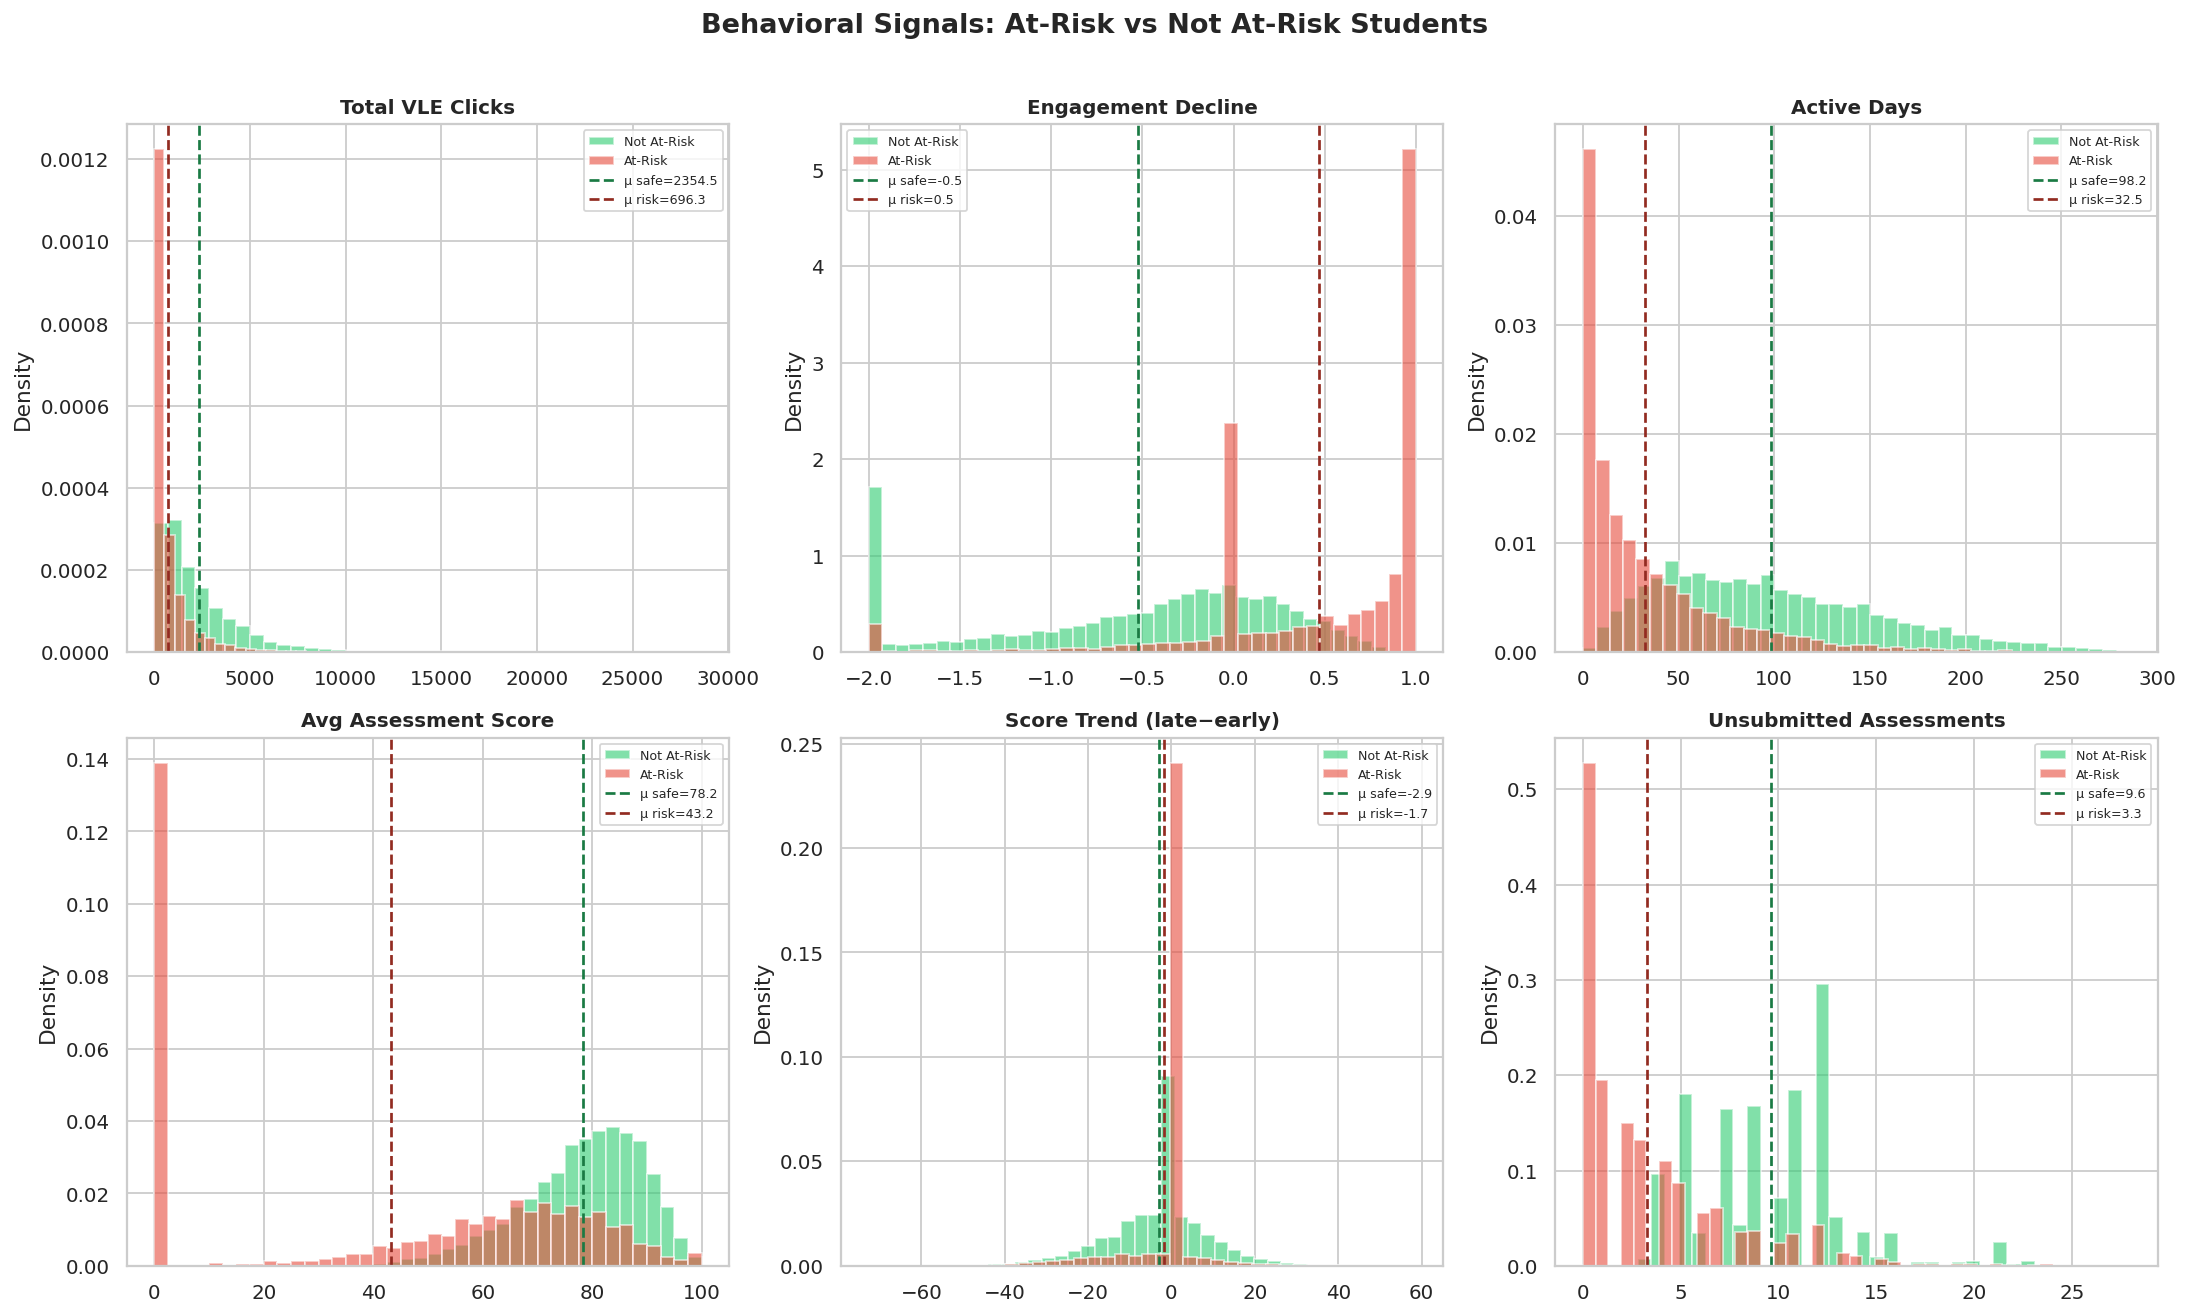

✅ Saved: plot3_behavioral_signals.png


In [ ]:
# ── CELL 10: PLOT 3 — Behavioral Signals ─────────────────────
FEATURES = [
    ('total_clicks',       'Total VLE Clicks'),
    ('engagement_decline', 'Engagement Decline'),
    ('active_days',        'Active Days'),
    ('mean_score',         'Avg Assessment Score'),
    ('score_trend',        'Score Trend (late−early)'),
    ('num_unsubmitted',    'Unsubmitted Assessments'),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Behavioral Signals: At-Risk vs Not At-Risk Students',
             fontsize=15, fontweight='bold', y=1.01)

for ax, (feat, label) in zip(axes.flatten(), FEATURES):
    not_risk = master[master['is_at_risk'] == 0][feat].dropna()
    at_risk  = master[master['is_at_risk'] == 1][feat].dropna()

    ax.hist(not_risk, bins=40, alpha=0.6, color='#2ecc71',
            label='Not At-Risk', density=True)
    ax.hist(at_risk,  bins=40, alpha=0.6, color='#e74c3c',
            label='At-Risk',     density=True)
    ax.axvline(not_risk.mean(), color='#1a7a43', linestyle='--', linewidth=1.5,
               label=f'μ safe={not_risk.mean():.1f}')
    ax.axvline(at_risk.mean(),  color='#922b21', linestyle='--', linewidth=1.5,
               label=f'μ risk={at_risk.mean():.1f}')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('plot3_behavioral_signals.png', bbox_inches='tight')
plt.show()
print("✅ Saved: plot3_behavioral_signals.png")

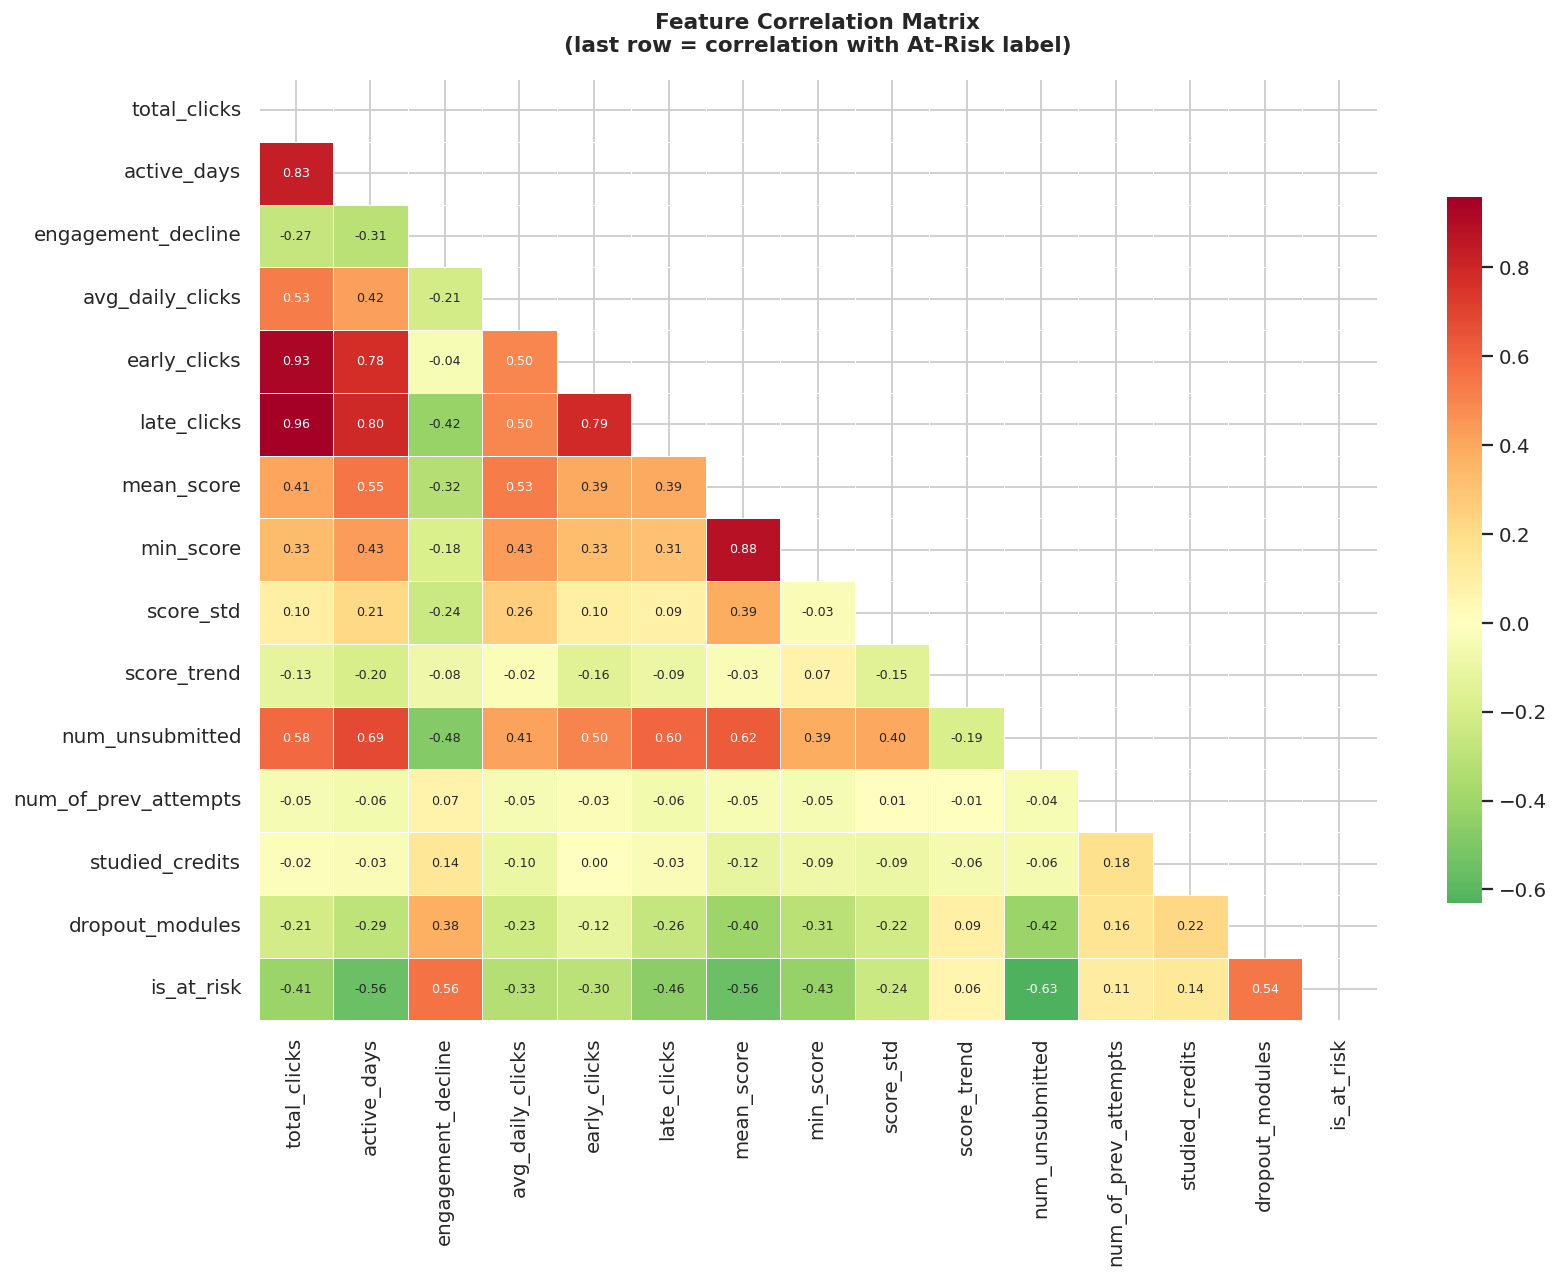

✅ Saved: plot4_correlation_heatmap.png


In [ ]:
# ── CELL 11: PLOT 4 — Correlation Heatmap ────────────────────
num_features = [
    'total_clicks', 'active_days', 'engagement_decline',
    'avg_daily_clicks', 'early_clicks', 'late_clicks',
    'mean_score', 'min_score', 'score_std', 'score_trend',
    'num_unsubmitted', 'num_of_prev_attempts',
    'studied_credits', 'dropout_modules', 'is_at_risk'
]

corr = master[num_features].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=0, ax=ax,
            linewidths=0.4, cbar_kws={"shrink": 0.75},
            annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix\n(last row = correlation with At-Risk label)',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot4_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("✅ Saved: plot4_correlation_heatmap.png")

In [ ]:
# ── CELL 12: Top Correlated Features ─────────────────────────
print("\n" + "="*55)
print("  📊 TOP FEATURES CORRELATED WITH AT-RISK LABEL")
print("="*55)
top_corr = (corr['is_at_risk']
            .drop('is_at_risk')
            .abs()
            .sort_values(ascending=False)
            .head(8))
for feat, val in top_corr.items():
    direction = ("↑ higher = more risk"
                 if corr['is_at_risk'][feat] > 0
                 else "↓ lower = more risk")
    print(f"  {feat:<30}  r={val:.3f}  ({direction})")


  📊 TOP FEATURES CORRELATED WITH AT-RISK LABEL
  num_unsubmitted                 r=0.630  (↓ lower = more risk)
  engagement_decline              r=0.562  (↑ higher = more risk)
  mean_score                      r=0.559  (↓ lower = more risk)
  active_days                     r=0.556  (↓ lower = more risk)
  dropout_modules                 r=0.537  (↑ higher = more risk)
  late_clicks                     r=0.461  (↓ lower = more risk)
  min_score                       r=0.429  (↓ lower = more risk)
  total_clicks                    r=0.412  (↓ lower = more risk)


In [ ]:
# ── CELL 13: Save Master Dataset ─────────────────────────────
Path("data").mkdir(exist_ok=True)
master.to_csv('data/master_dataset.csv', index=False)
print(f"\n✅ Saved: data/master_dataset.csv")
print(f"   {master.shape[0]:,} students × {master.shape[1]} features")
print("""
🎯 WEEK 1 COMPLETE
──────────────────────────────────────────
  data/master_dataset.csv          ← ML-ready for Week 2
  plot1_outcomes_demographics.png
  plot2_registration_patterns.png
  plot3_behavioral_signals.png
  plot4_correlation_heatmap.png
""")


✅ Saved: data/master_dataset.csv
   32,593 students × 35 features

🎯 WEEK 1 COMPLETE
──────────────────────────────────────────
  data/master_dataset.csv          ← ML-ready for Week 2
  plot1_outcomes_demographics.png
  plot2_registration_patterns.png
  plot3_behavioral_signals.png
  plot4_correlation_heatmap.png



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score, average_precision_score
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
sns.set_theme(style="whitegrid", palette="muted")

print("✅ All libraries imported")
print(f"   XGBoost version: {xgb.__version__}")

✅ All libraries imported
   XGBoost version: 3.2.0


In [ ]:
DATA = Path("/content/data/")

master = pd.read_csv(DATA / "master_dataset.csv")
courses = pd.read_csv(DATA / "courses.csv")

print(f"\n✅ Master dataset loaded: {master.shape[0]:,} students × {master.shape[1]} features")
print(f"   At-risk rate: {master['is_at_risk'].mean()*100:.1f}%")
print(f"\nColumn list:\n{list(master.columns)}")


✅ Master dataset loaded: 32,593 students × 35 features
   At-risk rate: 52.8%

Column list:
['id_student', 'code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'risk_level', 'is_at_risk', 'total_clicks', 'active_days', 'avg_daily_clicks', 'max_daily_clicks', 'first_activity', 'last_activity', 'engagement_span', 'early_clicks', 'late_clicks', 'engagement_decline', 'mean_score', 'min_score', 'max_score', 'score_std', 'num_assessments', 'num_unsubmitted', 'num_late', 'score_trend', 'num_modules_registered', 'avg_reg_delay', 'dropout_modules']


In [ ]:
# PROBLEM FROM WEEK 1:
# Students who withdrew early had fewer assessments available to them,
# so their raw num_unsubmitted was deceptively LOW.
# FIX: Merge with courses.csv to normalize clicks by module length.

print("\n⚙️  Applying Week 2 feature fixes...")

# Merge module length into master
master = master.merge(
    courses[['code_module', 'code_presentation', 'module_presentation_length']],
    on=['code_module', 'code_presentation'], how='left'
)
master['module_presentation_length'] = master['module_presentation_length'].fillna(
    master['module_presentation_length'].median()
)

# Normalized click features (per day of module)
master['clicks_per_day'] = (
    master['total_clicks'] / master['module_presentation_length']
).replace([np.inf, -np.inf], 0).fillna(0)

master['active_day_rate'] = (
    master['active_days'] / master['module_presentation_length']
).replace([np.inf, -np.inf], 0).fillna(0).clip(0, 1)

# Submission rate (normalize num_assessments taken vs module length proxy)
master['submission_rate'] = (
    master['num_assessments'] /
    (master['num_assessments'] + master['num_unsubmitted'] + 1)
).fillna(0)

# Early dropout flag: unregistered AND low engagement
master['early_dropout_flag'] = (
    (master['dropout_modules'] > 0) &
    (master['active_days'] < 10)
).astype(int)

print("✅ New normalized features added:")
print("   clicks_per_day, active_day_rate, submission_rate, early_dropout_flag")


⚙️  Applying Week 2 feature fixes...
✅ New normalized features added:
   clicks_per_day, active_day_rate, submission_rate, early_dropout_flag


In [ ]:
# Features to USE for modeling
FEATURES = [
    # VLE Engagement
    'total_clicks', 'active_days', 'engagement_decline',
    'avg_daily_clicks', 'early_clicks', 'late_clicks',
    'engagement_span', 'clicks_per_day', 'active_day_rate',

    # Assessment Performance
    'mean_score', 'min_score', 'max_score', 'score_std',
    'num_assessments', 'num_unsubmitted', 'submission_rate',
    'score_trend', 'num_late',

    # Registration Behavior
    'num_modules_registered', 'avg_reg_delay', 'dropout_modules',
    'early_dropout_flag',

    # Student Background
    'num_of_prev_attempts', 'studied_credits',
]

# Drop features with near-zero variance
TARGET = 'is_at_risk'

X = master[FEATURES].copy()
y = master[TARGET].copy()

# Final cleanup — replace any inf/nan
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"\n✅ Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"   Target: {y.sum():,} at-risk ({y.mean()*100:.1f}%)")


✅ Feature matrix: 32,593 rows × 24 features
   Target: 17,208 at-risk (52.8%)


In [ ]:
# 70% train | 15% validation | 15% test
# Stratified to preserve at-risk ratio in all splits

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\n✅ Data split:")
print(f"   Train      : {len(X_train):,} samples  ({y_train.mean()*100:.1f}% at-risk)")
print(f"   Validation : {len(X_val):,}  samples  ({y_val.mean()*100:.1f}% at-risk)")
print(f"   Test       : {len(X_test):,}  samples  ({y_test.mean()*100:.1f}% at-risk)")


✅ Data split:
   Train      : 22,815 samples  (52.8% at-risk)
   Validation : 4,889  samples  (52.8% at-risk)
   Test       : 4,889  samples  (52.8% at-risk)


In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # Fit ONLY on train
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("\n✅ Features scaled using StandardScaler (fit on train only)")


✅ Features scaled using StandardScaler (fit on train only)


In [ ]:
print("\n" + "="*55)
print("  MODEL 1: Logistic Regression (Baseline)")
print("="*55)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sc, y_train)

lr_val_proba = lr.predict_proba(X_val_sc)[:, 1]
lr_val_pred  = lr.predict(X_val_sc)
lr_auc       = roc_auc_score(y_val, lr_val_proba)
lr_f1        = f1_score(y_val, lr_val_pred)
lr_recall    = recall_score(y_val, lr_val_pred)
lr_precision = precision_score(y_val, lr_val_pred)

print(f"\n  Validation Results:")
print(f"  AUC-ROC   : {lr_auc:.4f}")
print(f"  F1 Score  : {lr_f1:.4f}")
print(f"  Precision : {lr_precision:.4f}")
print(f"  Recall    : {lr_recall:.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_val, lr_val_pred,
      target_names=['Not At-Risk', 'At-Risk']))


  MODEL 1: Logistic Regression (Baseline)

  Validation Results:
  AUC-ROC   : 0.9671
  F1 Score  : 0.9014
  Precision : 0.9421
  Recall    : 0.8640

  Classification Report:
              precision    recall  f1-score   support

 Not At-Risk       0.86      0.94      0.90      2308
     At-Risk       0.94      0.86      0.90      2581

    accuracy                           0.90      4889
   macro avg       0.90      0.90      0.90      4889
weighted avg       0.90      0.90      0.90      4889



In [ ]:
print("\n" + "="*55)
print("  MODEL 2: Random Forest")
print("="*55)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train)

rf_val_proba = rf.predict_proba(X_val_sc)[:, 1]
rf_val_pred  = rf.predict(X_val_sc)
rf_auc       = roc_auc_score(y_val, rf_val_proba)
rf_f1        = f1_score(y_val, rf_val_pred)
rf_recall    = recall_score(y_val, rf_val_pred)
rf_precision = precision_score(y_val, rf_val_pred)

print(f"\n  Validation Results:")
print(f"  AUC-ROC   : {rf_auc:.4f}")
print(f"  F1 Score  : {rf_f1:.4f}")
print(f"  Precision : {rf_precision:.4f}")
print(f"  Recall    : {rf_recall:.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_val, rf_val_pred,
      target_names=['Not At-Risk', 'At-Risk']))


  MODEL 2: Random Forest

  Validation Results:
  AUC-ROC   : 0.9744
  F1 Score  : 0.9058
  Precision : 0.9338
  Recall    : 0.8795

  Classification Report:
              precision    recall  f1-score   support

 Not At-Risk       0.87      0.93      0.90      2308
     At-Risk       0.93      0.88      0.91      2581

    accuracy                           0.90      4889
   macro avg       0.90      0.90      0.90      4889
weighted avg       0.91      0.90      0.90      4889



In [ ]:
print("\n" + "="*55)
print("  MODEL 3: XGBoost")
print("="*55)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_sc, y_train,
    eval_set=[(X_val_sc, y_val)],
    verbose=50
)

xgb_val_proba = xgb_model.predict_proba(X_val_sc)[:, 1]
xgb_val_pred  = xgb_model.predict(X_val_sc)
xgb_auc       = roc_auc_score(y_val, xgb_val_proba)
xgb_f1        = f1_score(y_val, xgb_val_pred)
xgb_recall    = recall_score(y_val, xgb_val_pred)
xgb_precision = precision_score(y_val, xgb_val_pred)

print(f"\n  Validation Results:")
print(f"  AUC-ROC   : {xgb_auc:.4f}")
print(f"  F1 Score  : {xgb_f1:.4f}")
print(f"  Precision : {xgb_precision:.4f}")
print(f"  Recall    : {xgb_recall:.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_val, xgb_val_pred,
      target_names=['Not At-Risk', 'At-Risk']))



  MODEL 3: XGBoost
[0]	validation_0-logloss:0.65831
[50]	validation_0-logloss:0.21722
[100]	validation_0-logloss:0.19157
[150]	validation_0-logloss:0.18977
[200]	validation_0-logloss:0.19121
[250]	validation_0-logloss:0.19318
[299]	validation_0-logloss:0.19482

  Validation Results:
  AUC-ROC   : 0.9754
  F1 Score  : 0.9110
  Precision : 0.9366
  Recall    : 0.8869

  Classification Report:
              precision    recall  f1-score   support

 Not At-Risk       0.88      0.93      0.91      2308
     At-Risk       0.94      0.89      0.91      2581

    accuracy                           0.91      4889
   macro avg       0.91      0.91      0.91      4889
weighted avg       0.91      0.91      0.91      4889



In [ ]:
print("\n" + "="*55)
print("  MODEL COMPARISON SUMMARY")
print("="*55)

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'AUC-ROC':   [lr_auc,       rf_auc,       xgb_auc],
    'F1':        [lr_f1,        rf_f1,        xgb_f1],
    'Precision': [lr_precision, rf_precision, xgb_precision],
    'Recall':    [lr_recall,    rf_recall,    xgb_recall],
})
results = results.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

best_model_name = results.iloc[0]['Model']
print(f"\n🏆 Best model: {best_model_name} (AUC-ROC = {results.iloc[0]['AUC-ROC']:.4f})")


  MODEL COMPARISON SUMMARY
              Model  AUC-ROC       F1  Precision   Recall
            XGBoost 0.975394 0.911045   0.936579 0.886866
      Random Forest 0.974416 0.905826   0.933772 0.879504
Logistic Regression 0.967143 0.901374   0.942121 0.864006

🏆 Best model: XGBoost (AUC-ROC = 0.9754)


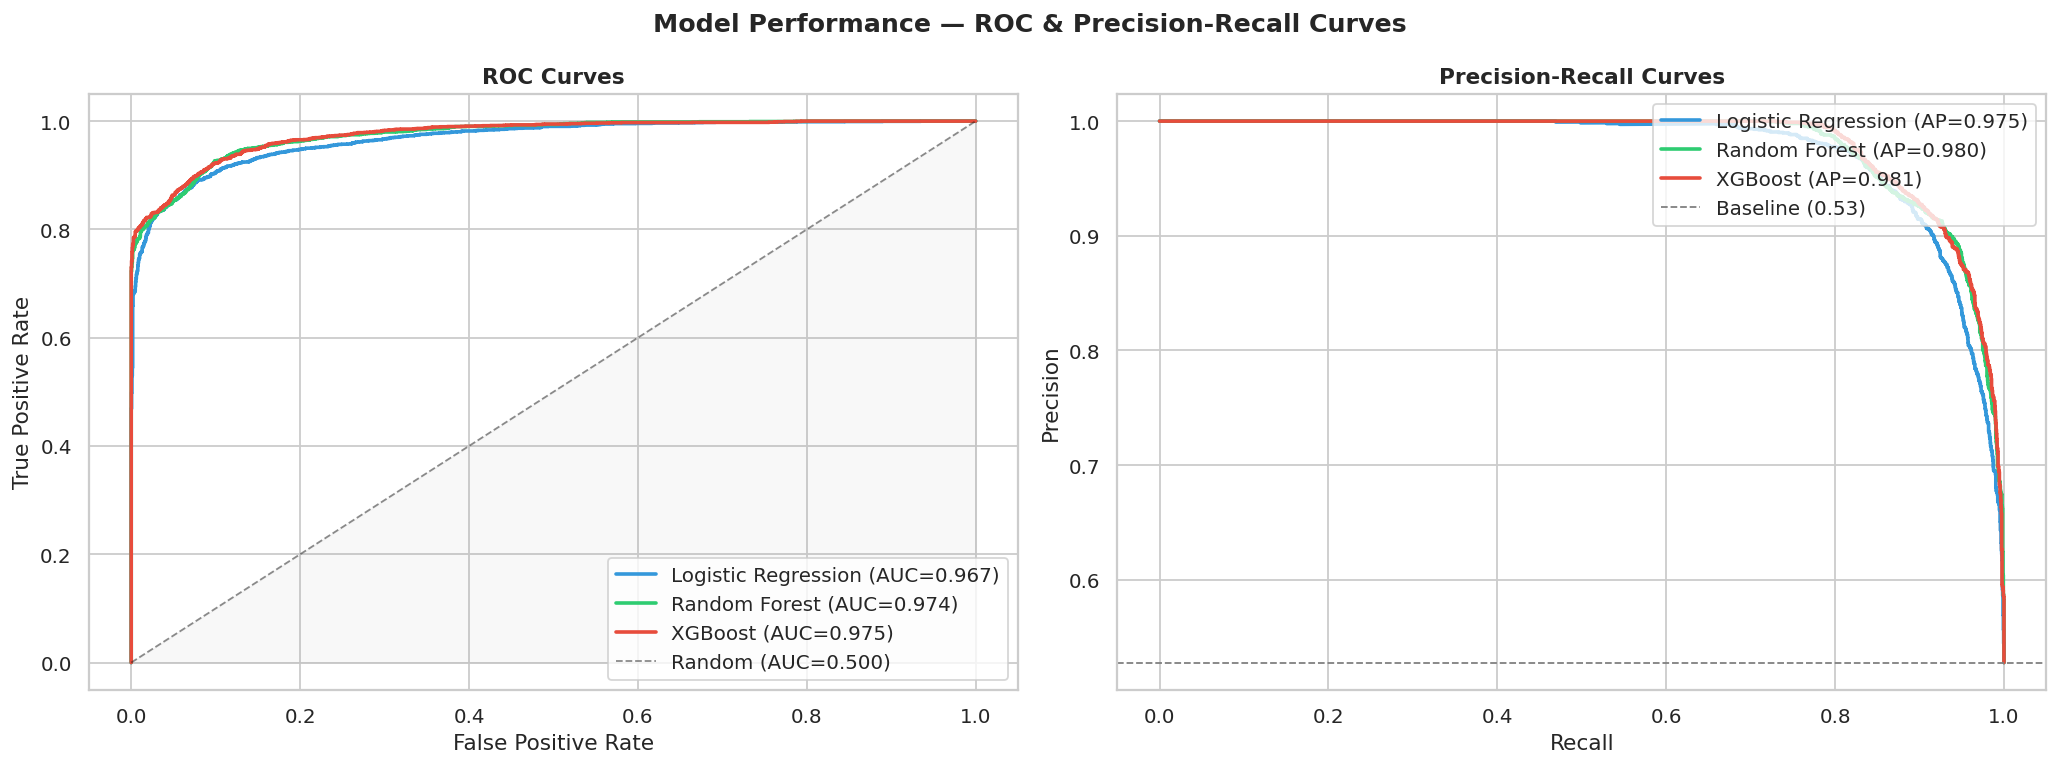

✅ Saved: plot5_roc_pr_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Model Performance — ROC & Precision-Recall Curves",
             fontsize=14, fontweight='bold')

model_data = [
    ("Logistic Regression", lr_val_proba,  '#3498db'),
    ("Random Forest",       rf_val_proba,  '#2ecc71'),
    ("XGBoost",             xgb_val_proba, '#e74c3c'),
]

# ROC Curves
for name, proba, color in model_data:
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc:.3f})")

axes[0].plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random (AUC=0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].fill_between([0,1],[0,1], alpha=0.05, color='gray')

# Precision-Recall Curves
for name, proba, color in model_data:
    prec, rec, _ = precision_recall_curve(y_val, proba)
    ap = average_precision_score(y_val, proba)
    axes[1].plot(rec, prec, color=color, lw=2, label=f"{name} (AP={ap:.3f})")

baseline_pr = y_val.mean()
axes[1].axhline(y=baseline_pr, color='gray', linestyle='--', lw=1,
                label=f'Baseline ({baseline_pr:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('plot5_roc_pr_curves.png', bbox_inches='tight')
plt.show()
print("✅ Saved: plot5_roc_pr_curves.png")

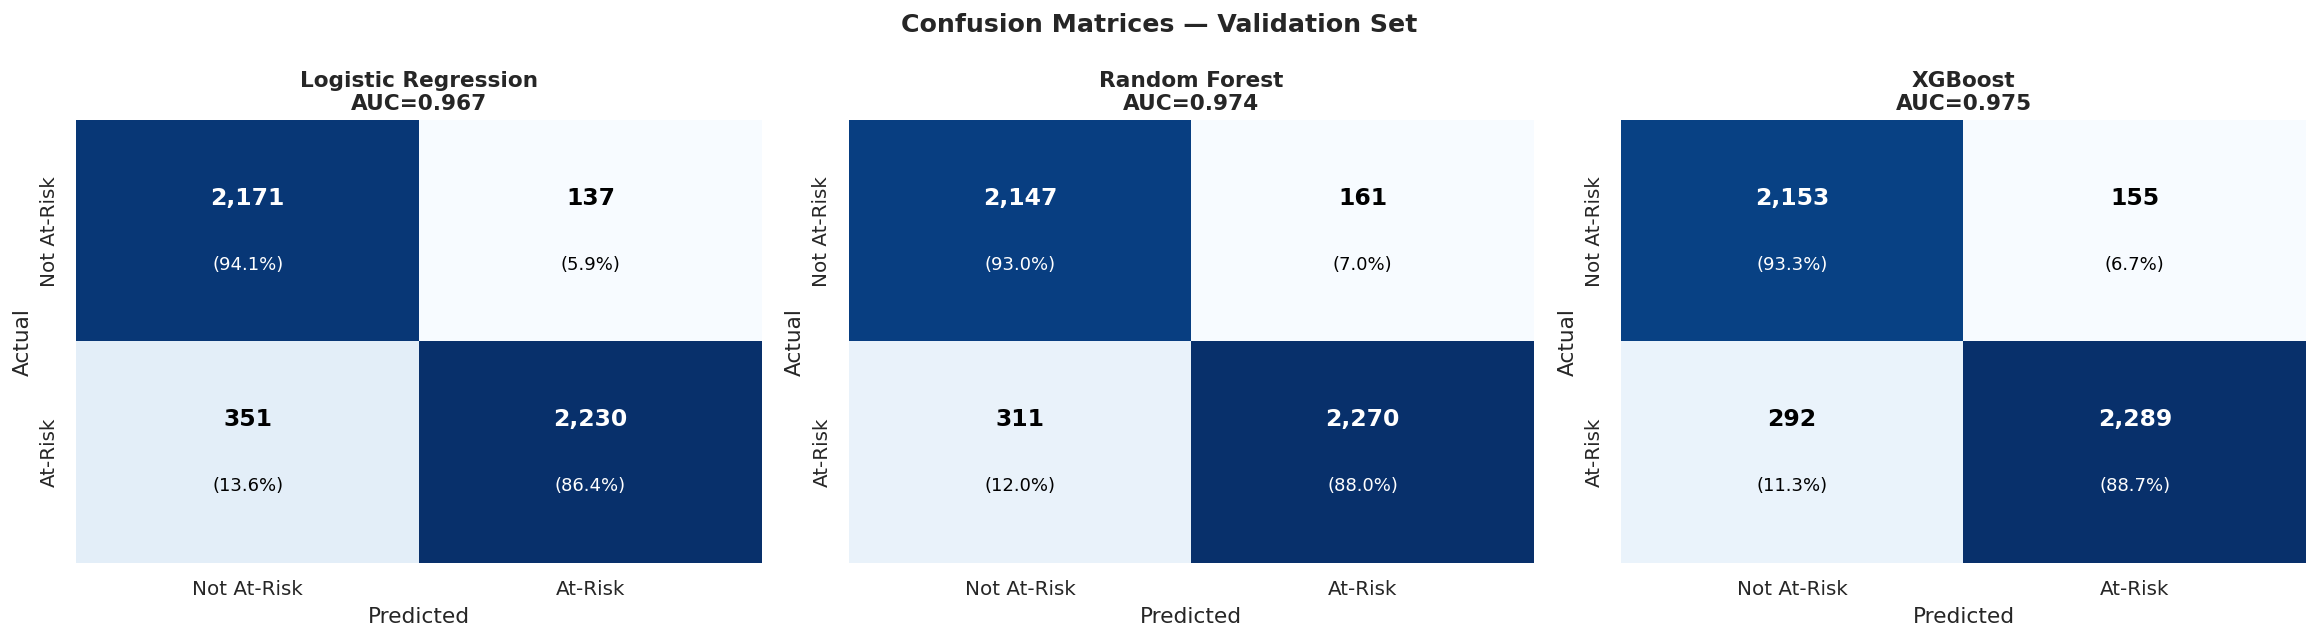

✅ Saved: plot6_confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — Validation Set", fontsize=14, fontweight='bold')

for ax, (name, pred) in zip(axes, [
    ("Logistic Regression", lr_val_pred),
    ("Random Forest",       rf_val_pred),
    ("XGBoost",             xgb_val_pred),
]):
    cm = confusion_matrix(y_val, pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not At-Risk','At-Risk'],
                yticklabels=['Not At-Risk','At-Risk'],
                cbar=False)

    # Annotate with count + percentage
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.35, f'{cm[i,j]:,}',
                    ha='center', va='center', fontsize=13, fontweight='bold',
                    color='white' if cm_pct[i,j] > 50 else 'black')
            ax.text(j+0.5, i+0.65, f'({cm_pct[i,j]:.1f}%)',
                    ha='center', va='center', fontsize=10,
                    color='white' if cm_pct[i,j] > 50 else 'black')

    auc = roc_auc_score(y_val, {
        "Logistic Regression": lr_val_proba,
        "Random Forest":       rf_val_proba,
        "XGBoost":             xgb_val_proba
    }[name])

    ax.set_title(f"{name}\nAUC={auc:.3f}", fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('plot6_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("✅ Saved: plot6_confusion_matrices.png")

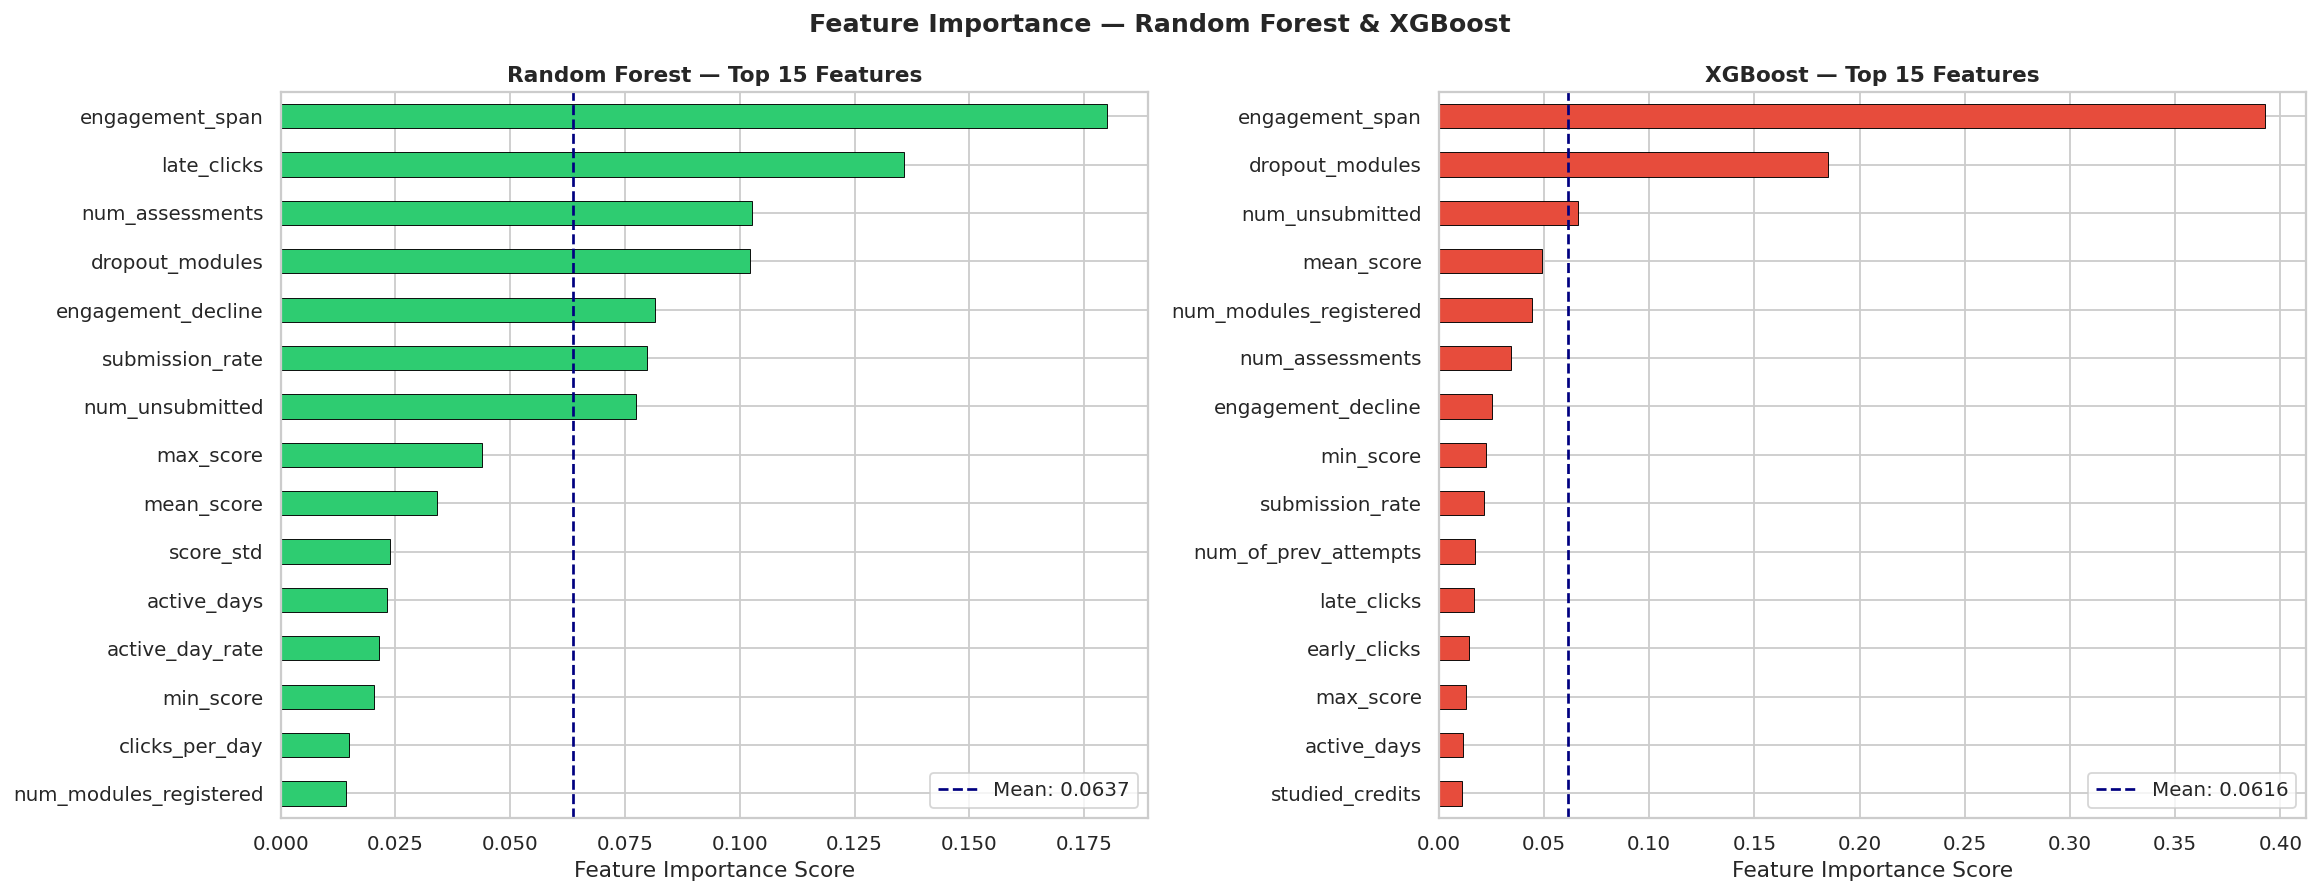

✅ Saved: plot7_feature_importance.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Feature Importance — Random Forest & XGBoost",
             fontsize=14, fontweight='bold')

for ax, (model, name, color) in zip(axes, [
    (rf,        "Random Forest", '#2ecc71'),
    (xgb_model, "XGBoost",       '#e74c3c'),
]):
    importances = pd.Series(
        model.feature_importances_, index=FEATURES
    ).sort_values(ascending=True).tail(15)

    importances.plot(kind='barh', ax=ax, color=color, edgecolor='black', linewidth=0.5)
    ax.set_title(f"{name} — Top 15 Features", fontweight='bold')
    ax.set_xlabel('Feature Importance Score')
    ax.axvline(importances.mean(), color='navy', linestyle='--', lw=1.5,
               label=f'Mean: {importances.mean():.4f}')
    ax.legend()

plt.tight_layout()
plt.savefig('plot7_feature_importance.png', bbox_inches='tight')
plt.show()
print("✅ Saved: plot7_feature_importance.png")

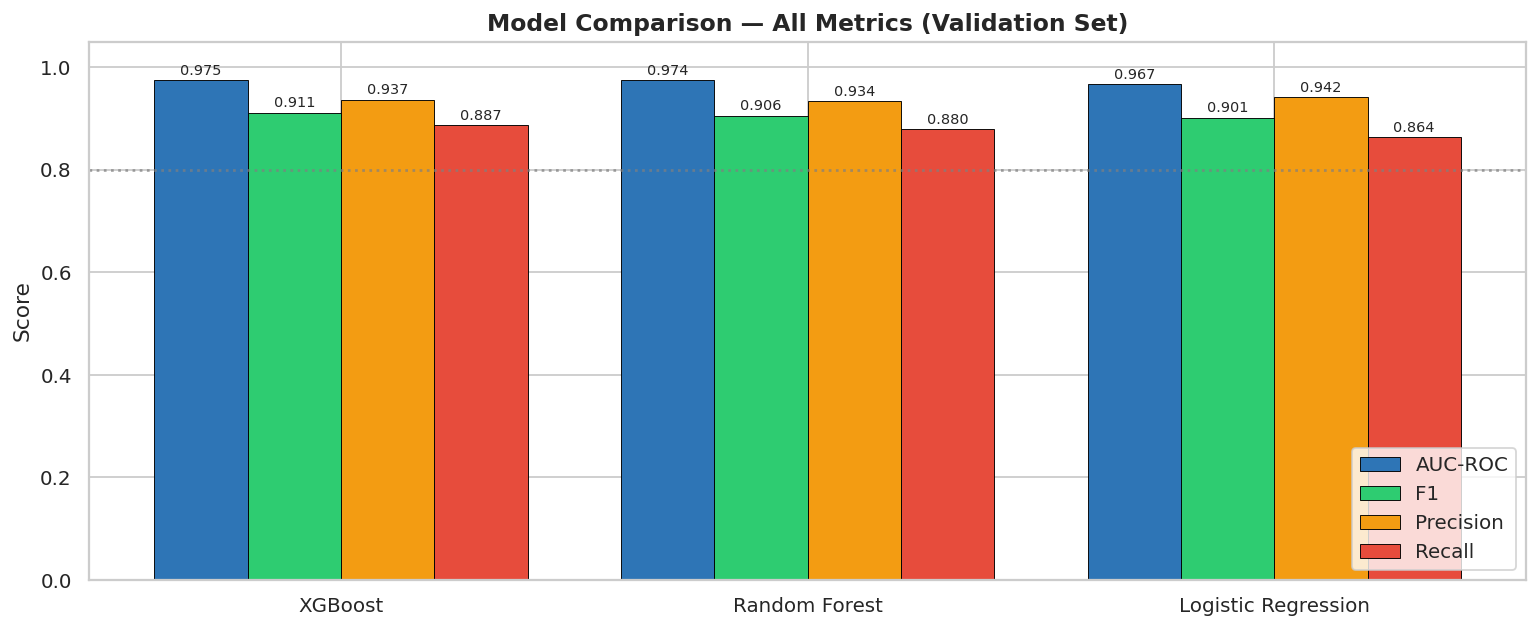

✅ Saved: plot8_model_comparison.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(results))
width = 0.20
metrics = ['AUC-ROC', 'F1', 'Precision', 'Recall']
colors  = ['#2E75B6', '#2ecc71', '#f39c12', '#e74c3c']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = results[metric].values
    bars = ax.bar(x + i*width, vals, width, label=metric, color=color,
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results['Model'], fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics (Validation Set)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(0.80, color='gray', linestyle=':', lw=1.5,
           label='Target AUC=0.80', alpha=0.7)

plt.tight_layout()
plt.savefig('plot8_model_comparison.png', bbox_inches='tight')
plt.show()
print("✅ Saved: plot8_model_comparison.png")

In [ ]:
print("\n" + "="*55)
print("  5-FOLD CROSS-VALIDATION (on full training data)")
print("="*55)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model, name in [
    (LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
     "Logistic Regression"),
    (RandomForestClassifier(n_estimators=100, max_depth=10,
                            class_weight='balanced', random_state=42, n_jobs=-1),
     "Random Forest"),
    (xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.05,
                       scale_pos_weight=scale_pos_weight,
                       use_label_encoder=False, eval_metric='logloss',
                       random_state=42, n_jobs=-1),
     "XGBoost"),
]:
    scores = cross_val_score(model, X_train_sc, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f"  {name:<25} AUC: {scores.mean():.4f} ± {scores.std():.4f}  "
          f"(folds: {[f'{s:.3f}' for s in scores]})")


  5-FOLD CROSS-VALIDATION (on full training data)
  Logistic Regression       AUC: 0.9646 ± 0.0020  (folds: ['0.962', '0.967', '0.964', '0.967', '0.963'])
  Random Forest             AUC: 0.9721 ± 0.0013  (folds: ['0.970', '0.972', '0.972', '0.974', '0.971'])
  XGBoost                   AUC: 0.9734 ± 0.0012  (folds: ['0.972', '0.974', '0.974', '0.975', '0.972'])


In [ ]:
print("\n" + "="*55)
print("  FINAL EVALUATION ON HELD-OUT TEST SET")
print("="*55)
print("  ⚠️  Run ONCE at the very end — test set is untouched until now")
print()

# Use XGBoost (expected best) — change if Random Forest won
best_model   = xgb_model
best_proba   = best_model.predict_proba(X_test_sc)[:, 1]
best_pred    = best_model.predict(X_test_sc)
test_auc     = roc_auc_score(y_test, best_proba)
test_f1      = f1_score(y_test, best_pred)
test_recall  = recall_score(y_test, best_pred)
test_prec    = precision_score(y_test, best_pred)

print(f"  Best Model : XGBoost")
print(f"  Test AUC-ROC  : {test_auc:.4f}")
print(f"  Test F1       : {test_f1:.4f}")
print(f"  Test Precision: {test_prec:.4f}")
print(f"  Test Recall   : {test_recall:.4f}")
print()
print(classification_report(y_test, best_pred,
      target_names=['Not At-Risk', 'At-Risk']))


  FINAL EVALUATION ON HELD-OUT TEST SET
  ⚠️  Run ONCE at the very end — test set is untouched until now

  Best Model : XGBoost
  Test AUC-ROC  : 0.9739
  Test F1       : 0.9085
  Test Precision: 0.9356
  Test Recall   : 0.8830

              precision    recall  f1-score   support

 Not At-Risk       0.88      0.93      0.90      2308
     At-Risk       0.94      0.88      0.91      2581

    accuracy                           0.91      4889
   macro avg       0.91      0.91      0.91      4889
weighted avg       0.91      0.91      0.91      4889



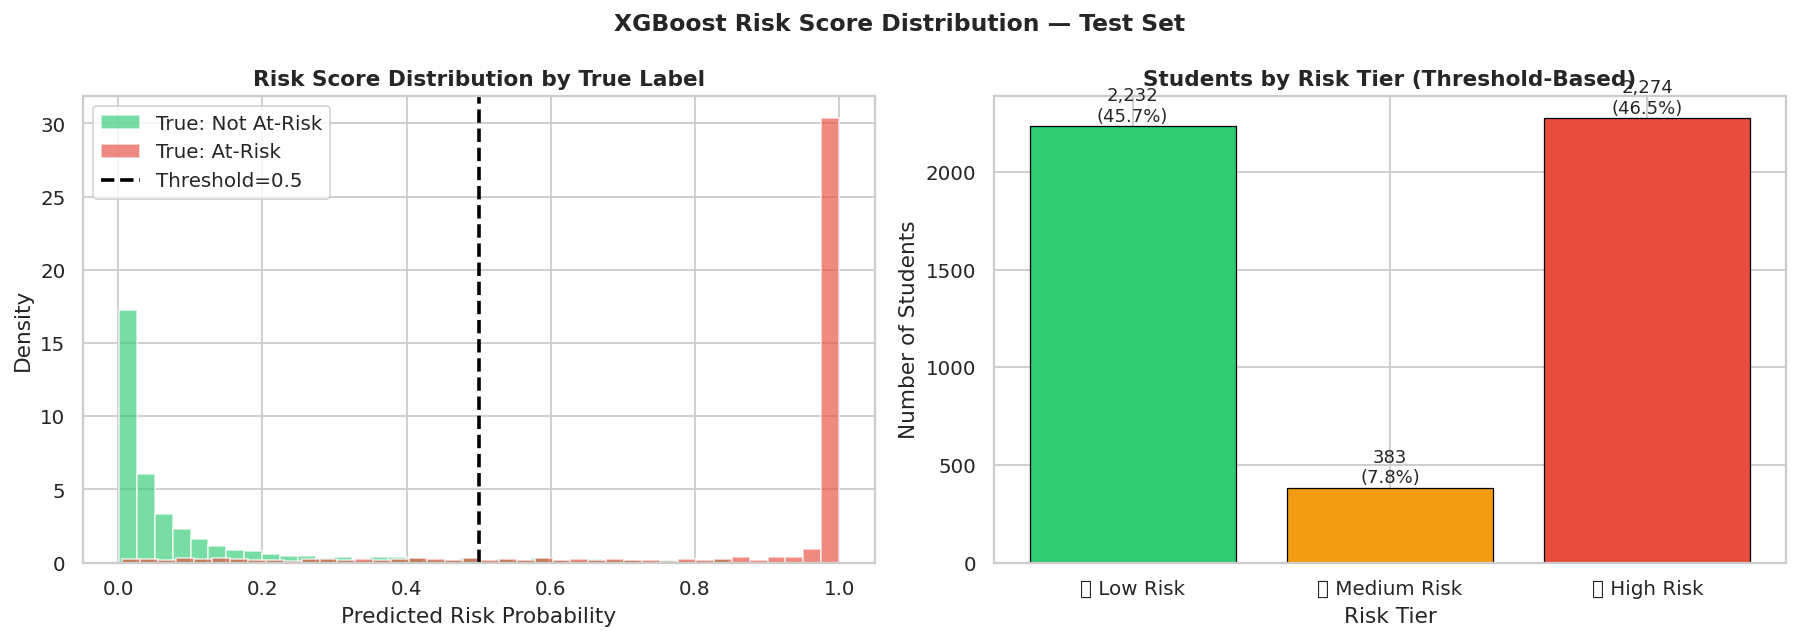

✅ Saved: plot9_risk_score_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("XGBoost Risk Score Distribution — Test Set",
             fontsize=13, fontweight='bold')

# Score distribution by true label
not_risk_scores = best_proba[y_test == 0]
at_risk_scores  = best_proba[y_test == 1]

axes[0].hist(not_risk_scores, bins=40, alpha=0.65,
             color='#2ecc71', label='True: Not At-Risk', density=True)
axes[0].hist(at_risk_scores,  bins=40, alpha=0.65,
             color='#e74c3c', label='True: At-Risk',     density=True)
axes[0].axvline(0.5, color='black', linestyle='--', lw=2, label='Threshold=0.5')
axes[0].set_xlabel('Predicted Risk Probability')
axes[0].set_ylabel('Density')
axes[0].set_title('Risk Score Distribution by True Label', fontweight='bold')
axes[0].legend()

# Risk tier breakdown
tiers = pd.cut(best_proba,
               bins=[0, 0.33, 0.66, 1.0],
               labels=['🟢 Low Risk', '🟡 Medium Risk', '🔴 High Risk'])
tier_counts = tiers.value_counts().sort_index()

bars = axes[1].bar(tier_counts.index, tier_counts.values,
                   color=['#2ecc71', '#f39c12', '#e74c3c'],
                   edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, tier_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'{val:,}\n({val/len(best_proba)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)

axes[1].set_title('Students by Risk Tier (Threshold-Based)', fontweight='bold')
axes[1].set_ylabel('Number of Students')
axes[1].set_xlabel('Risk Tier')

plt.tight_layout()
plt.savefig('plot9_risk_score_distribution.png', bbox_inches='tight')
plt.show()
print("✅ Saved: plot9_risk_score_distribution.png")

In [ ]:
import joblib

Path("models/").mkdir(exist_ok=True)

joblib.dump(xgb_model,  'models/xgb_model.pkl')
joblib.dump(rf,         'models/rf_model.pkl')
joblib.dump(lr,         'models/lr_model.pkl')
joblib.dump(scaler,     'models/scaler.pkl')

# Save predictions on full dataset for dashboard use
master_scored = master[['id_student','code_module','code_presentation',
                          'gender','age_band','imd_band','final_result',
                          'is_at_risk']].copy()

X_full = master[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0)
X_full_sc = scaler.transform(X_full)
master_scored['risk_score']    = xgb_model.predict_proba(X_full_sc)[:, 1]
master_scored['risk_tier']     = pd.cut(
    master_scored['risk_score'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Low', 'Medium', 'High']
)
master_scored['predicted_risk'] = xgb_model.predict(X_full_sc)

master_scored.to_csv('data/scored_students.csv', index=False)

print(f"\n✅ Models saved to models/")
print(f"   xgb_model.pkl, rf_model.pkl, lr_model.pkl, scaler.pkl")
print(f"✅ Scored students saved → data/scored_students.csv")
print(f"   {len(master_scored):,} students with risk scores")

print(f"""
🎯 WEEK 2 COMPLETE
──────────────────────────────────────────────────
  Models trained   : Logistic Regression, Random Forest, XGBoost
  Best model       : Check AUC-ROC above (target: > 0.80)
  Key output file  : data/scored_students.csv  ← feeds the dashboard

  Plots generated:
    plot5_roc_pr_curves.png
    plot6_confusion_matrices.png
    plot7_feature_importance.png
    plot8_model_comparison.png
    plot9_risk_score_distribution.png

  Saved models:
    models/xgb_model.pkl
    models/rf_model.pkl
    models/lr_model.pkl
    models/scaler.pkl

  Next → Week 3: SHAP explainability + dashboard build
""")


✅ Models saved to models/
   xgb_model.pkl, rf_model.pkl, lr_model.pkl, scaler.pkl
✅ Scored students saved → data/scored_students.csv
   32,593 students with risk scores

🎯 WEEK 2 COMPLETE
──────────────────────────────────────────────────
  Models trained   : Logistic Regression, Random Forest, XGBoost
  Best model       : Check AUC-ROC above (target: > 0.80)
  Key output file  : data/scored_students.csv  ← feeds the dashboard
 
  Plots generated:
    plot5_roc_pr_curves.png
    plot6_confusion_matrices.png
    plot7_feature_importance.png
    plot8_model_comparison.png
    plot9_risk_score_distribution.png
 
  Saved models:
    models/xgb_model.pkl
    models/rf_model.pkl
    models/lr_model.pkl
    models/scaler.pkl
 
  Next → Week 3: SHAP explainability + dashboard build



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
sns.set_theme(style="whitegrid")

print("✅ Libraries loaded")
print(f"   SHAP version: {shap.__version__}")


✅ Libraries loaded
   SHAP version: 0.51.0


In [ ]:
DATA   = Path("/content/data/")
MODELS = Path("/content/models/")

master  = pd.read_csv(DATA / "master_dataset.csv")
scored  = pd.read_csv(DATA / "scored_students.csv")

xgb_model = joblib.load(MODELS / "xgb_model.pkl")
rf_model  = joblib.load(MODELS / "rf_model.pkl")
scaler    = joblib.load(MODELS / "scaler.pkl")

FEATURES = [
    'total_clicks', 'active_days', 'engagement_decline',
    'avg_daily_clicks', 'early_clicks', 'late_clicks',
    'engagement_span', 'clicks_per_day', 'active_day_rate',
    'mean_score', 'min_score', 'max_score', 'score_std',
    'num_assessments', 'num_unsubmitted', 'submission_rate',
    'score_trend', 'num_late',
    'num_modules_registered', 'avg_reg_delay', 'dropout_modules',
    'early_dropout_flag',
    'num_of_prev_attempts', 'studied_credits',
]

# Add normalized features if missing
courses = pd.read_csv(DATA / "courses.csv")
master = master.merge(
    courses[['code_module','code_presentation','module_presentation_length']],
    on=['code_module','code_presentation'], how='left'
)
master['module_presentation_length'] = master['module_presentation_length'].fillna(
    master['module_presentation_length'].median()
)
master['clicks_per_day']   = (master['total_clicks'] / master['module_presentation_length']).replace([np.inf,-np.inf],0).fillna(0)
master['active_day_rate']  = (master['active_days']  / master['module_presentation_length']).replace([np.inf,-np.inf],0).fillna(0).clip(0,1)
master['submission_rate']  = (master['num_assessments'] / (master['num_assessments'] + master['num_unsubmitted'] + 1)).fillna(0)
master['early_dropout_flag'] = ((master['dropout_modules'] > 0) & (master['active_days'] < 10)).astype(int)

X_full = master[FEATURES].replace([np.inf,-np.inf], np.nan).fillna(0)
X_full_sc = scaler.transform(X_full)
y_full = master['is_at_risk']

print(f"✅ Loaded: {len(master):,} students | {len(FEATURES)} features")

✅ Loaded: 32,593 students | 24 features


In [ ]:
print("\n⏳ Computing SHAP values (may take 1-2 min)...")

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_full_sc)

# Convert to DataFrame for easy analysis
shap_df = pd.DataFrame(shap_values, columns=FEATURES)
print(f"✅ SHAP values computed: {shap_df.shape}")

# Mean absolute SHAP per feature
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)
print(f"\n📊 Top 10 features by mean |SHAP|:")
for feat, val in mean_abs_shap.head(10).items():
    print(f"   {feat:<30} {val:.4f}")


⏳ Computing SHAP values (may take 1-2 min)...
✅ SHAP values computed: (32593, 24)

📊 Top 10 features by mean |SHAP|:
   engagement_span                2.0030
   dropout_modules                0.7323
   mean_score                     0.6852
   engagement_decline             0.5392
   num_unsubmitted                0.5280
   late_clicks                    0.3465
   submission_rate                0.2866
   early_clicks                   0.2068
   num_assessments                0.1878
   min_score                      0.1632



⏳ Generating SHAP plots...


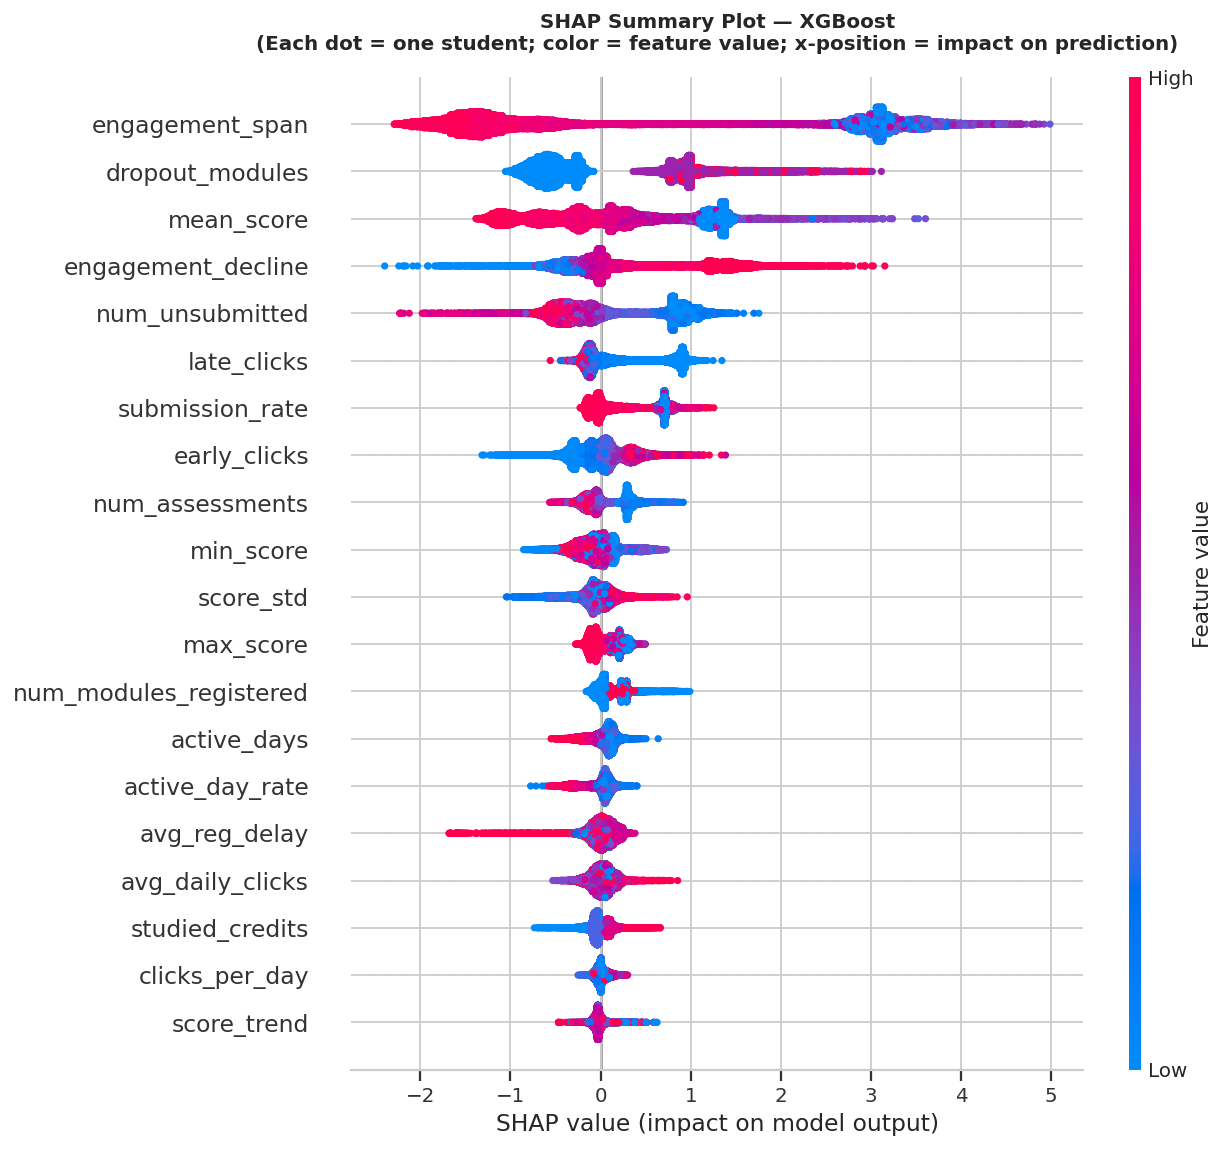

✅ Saved: plot10_shap_summary.png


In [ ]:
print("\n⏳ Generating SHAP plots...")

fig, ax = plt.subplots(figsize=(10, 9))
shap.summary_plot(
    shap_values, X_full_sc,
    feature_names=FEATURES,
    max_display=20,
    show=False,
    plot_size=None
)
plt.title("SHAP Summary Plot — XGBoost\n(Each dot = one student; color = feature value; x-position = impact on prediction)",
          fontsize=11, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('/content/plot10_shap_summary.png', bbox_inches='tight')
plt.show()
print("✅ Saved: plot10_shap_summary.png")

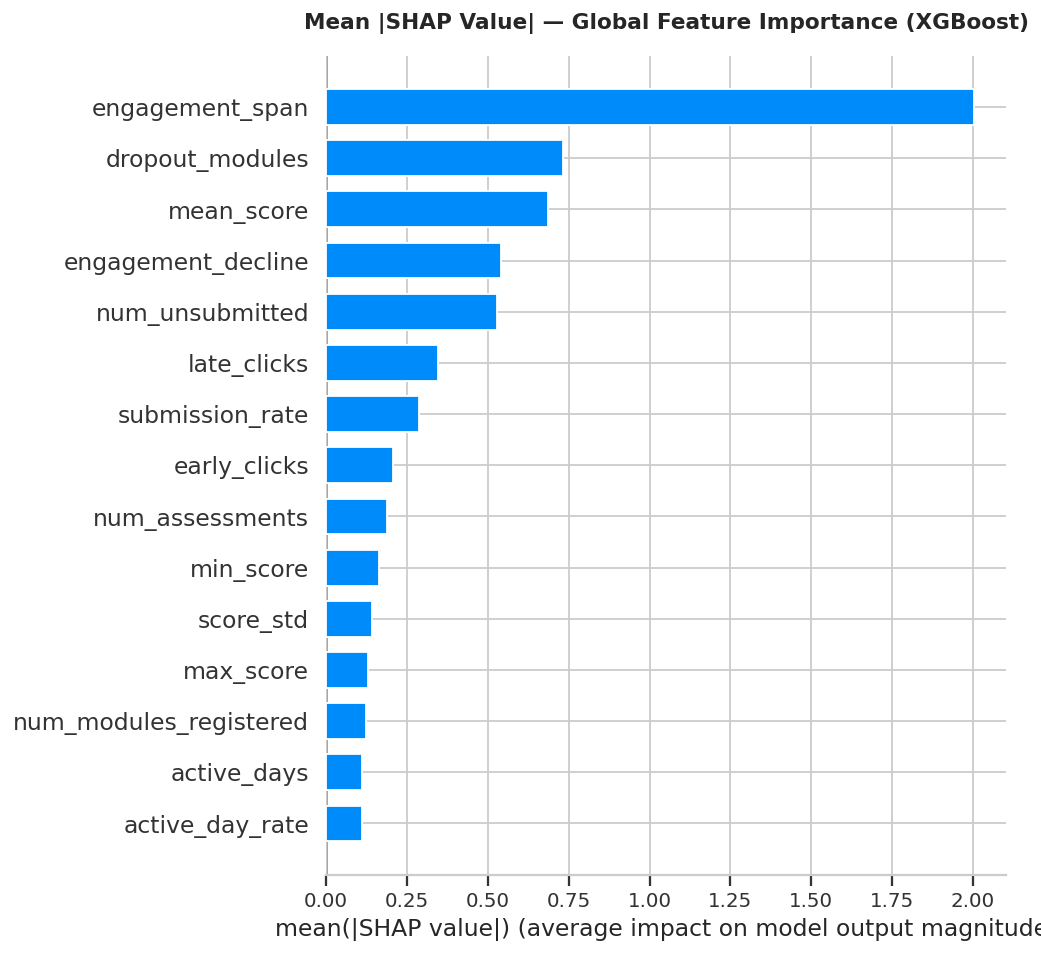

✅ Saved: plot11_shap_bar.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_full_sc,
    feature_names=FEATURES,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Mean |SHAP Value| — Global Feature Importance (XGBoost)",
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('/content/plot11_shap_bar.png', bbox_inches='tight')
plt.show()
print("✅ Saved: plot11_shap_bar.png")

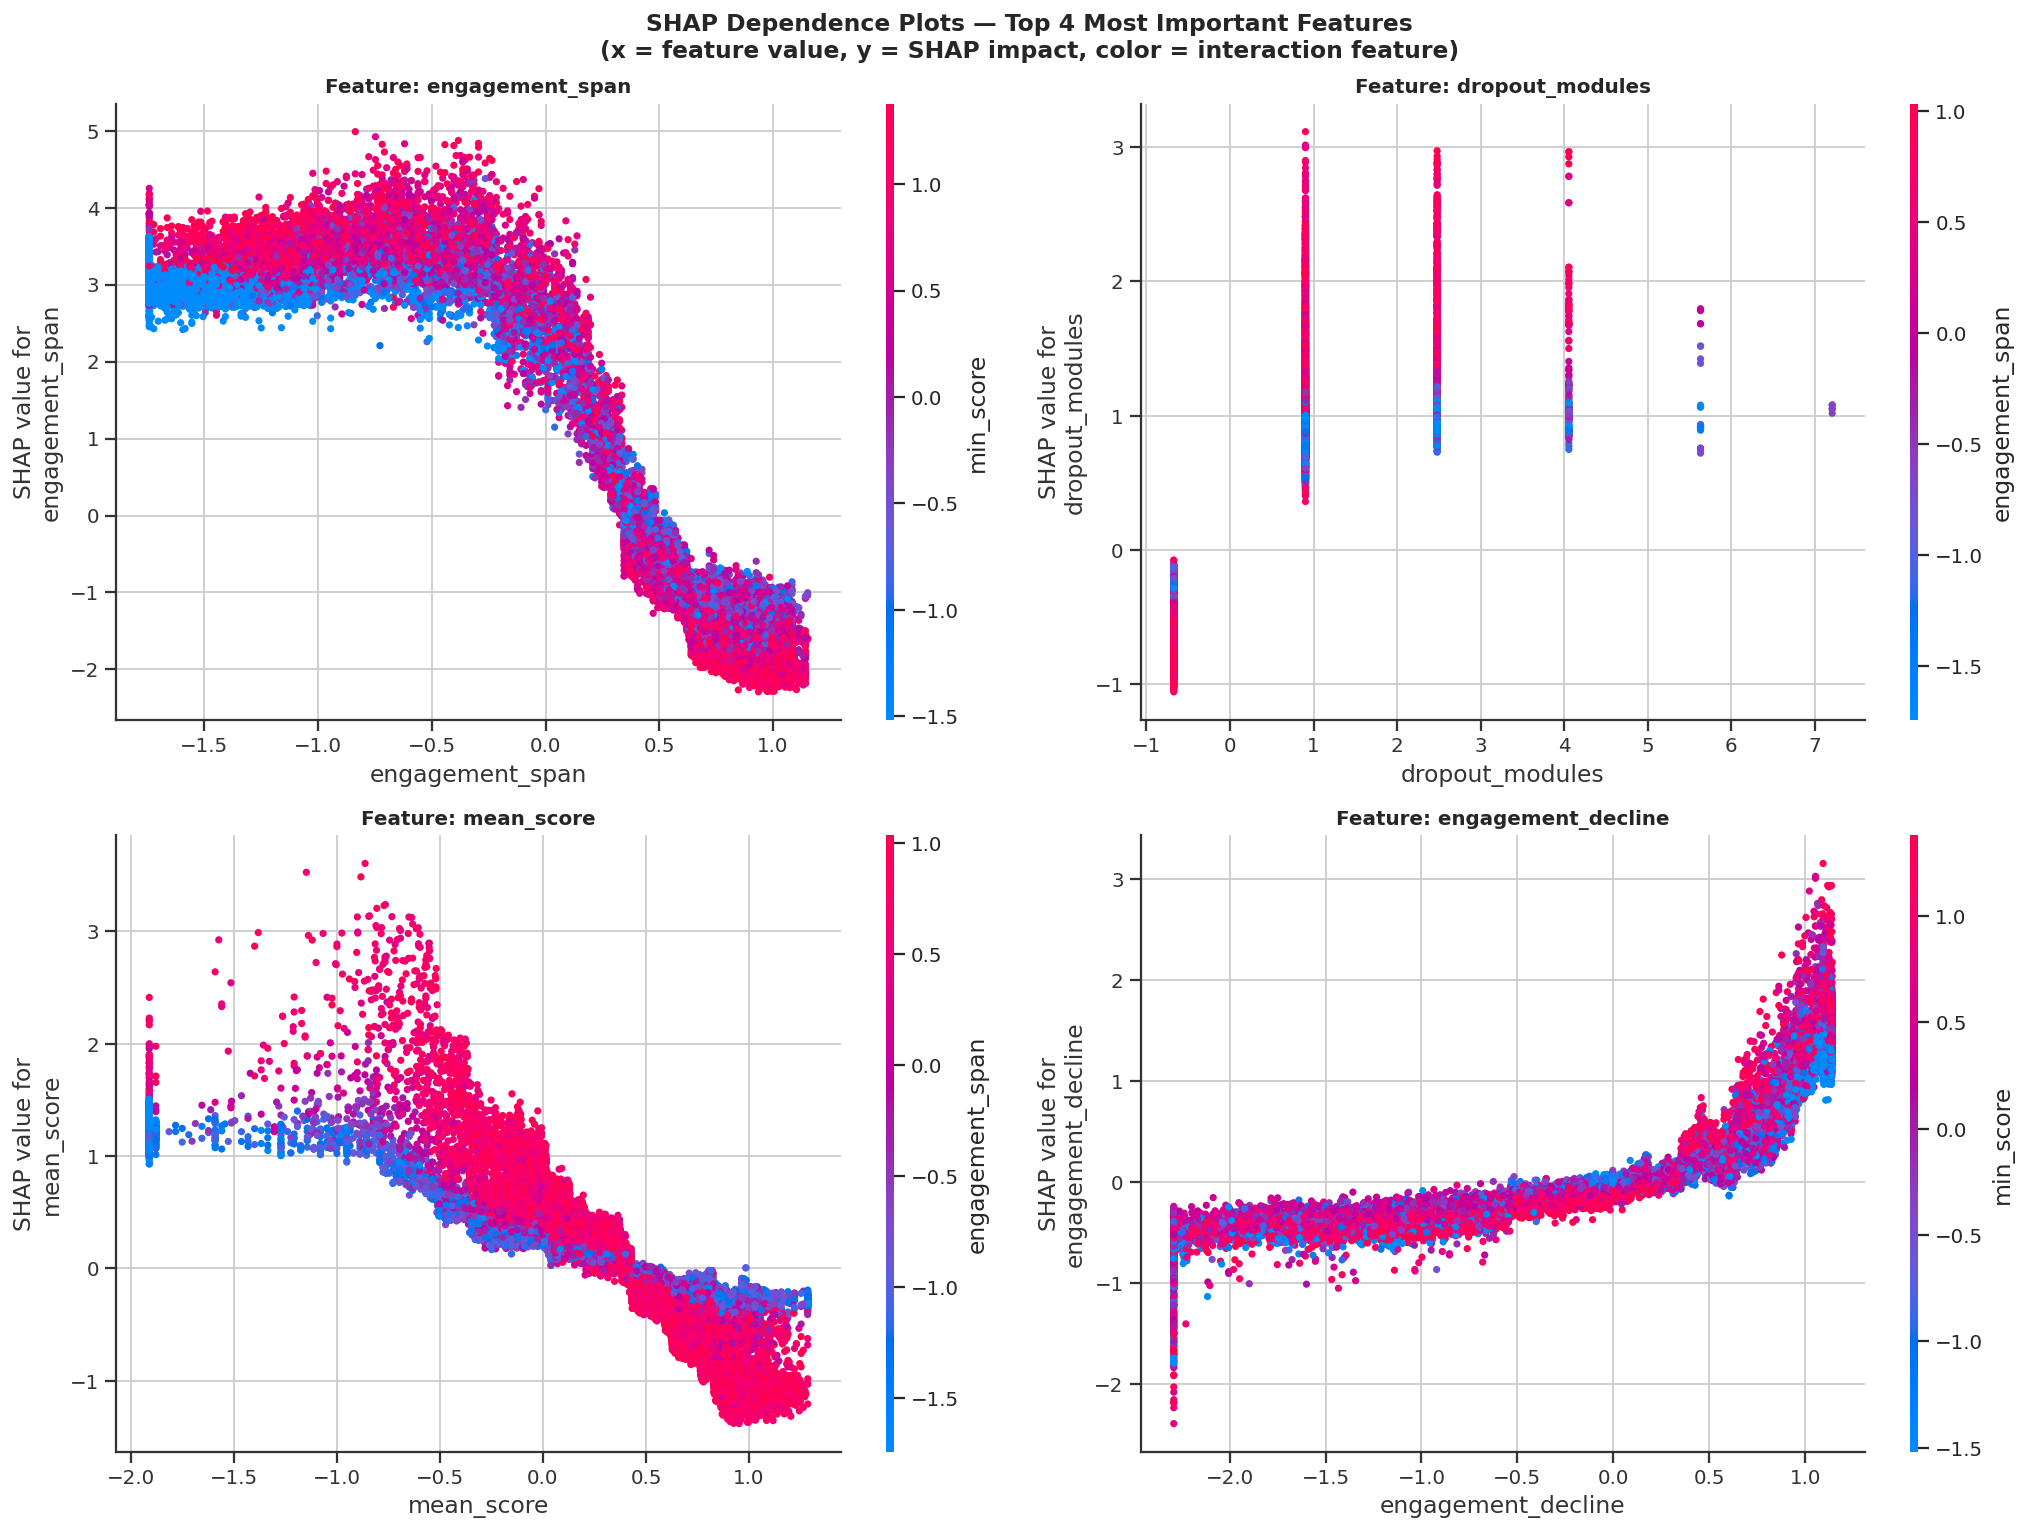

✅ Saved: plot12_shap_dependence.png


In [ ]:
top4 = mean_abs_shap.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("SHAP Dependence Plots — Top 4 Most Important Features\n"
             "(x = feature value, y = SHAP impact, color = interaction feature)",
             fontsize=13, fontweight='bold')

for ax, feat in zip(axes.flatten(), top4):
    feat_idx = FEATURES.index(feat)
    shap.dependence_plot(
        feat_idx, shap_values, X_full_sc,
        feature_names=FEATURES,
        ax=ax, show=False
    )
    ax.set_title(f"Feature: {feat}", fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('/content/plot12_shap_dependence.png', bbox_inches='tight')
plt.show()
print("✅ Saved: plot12_shap_dependence.png")

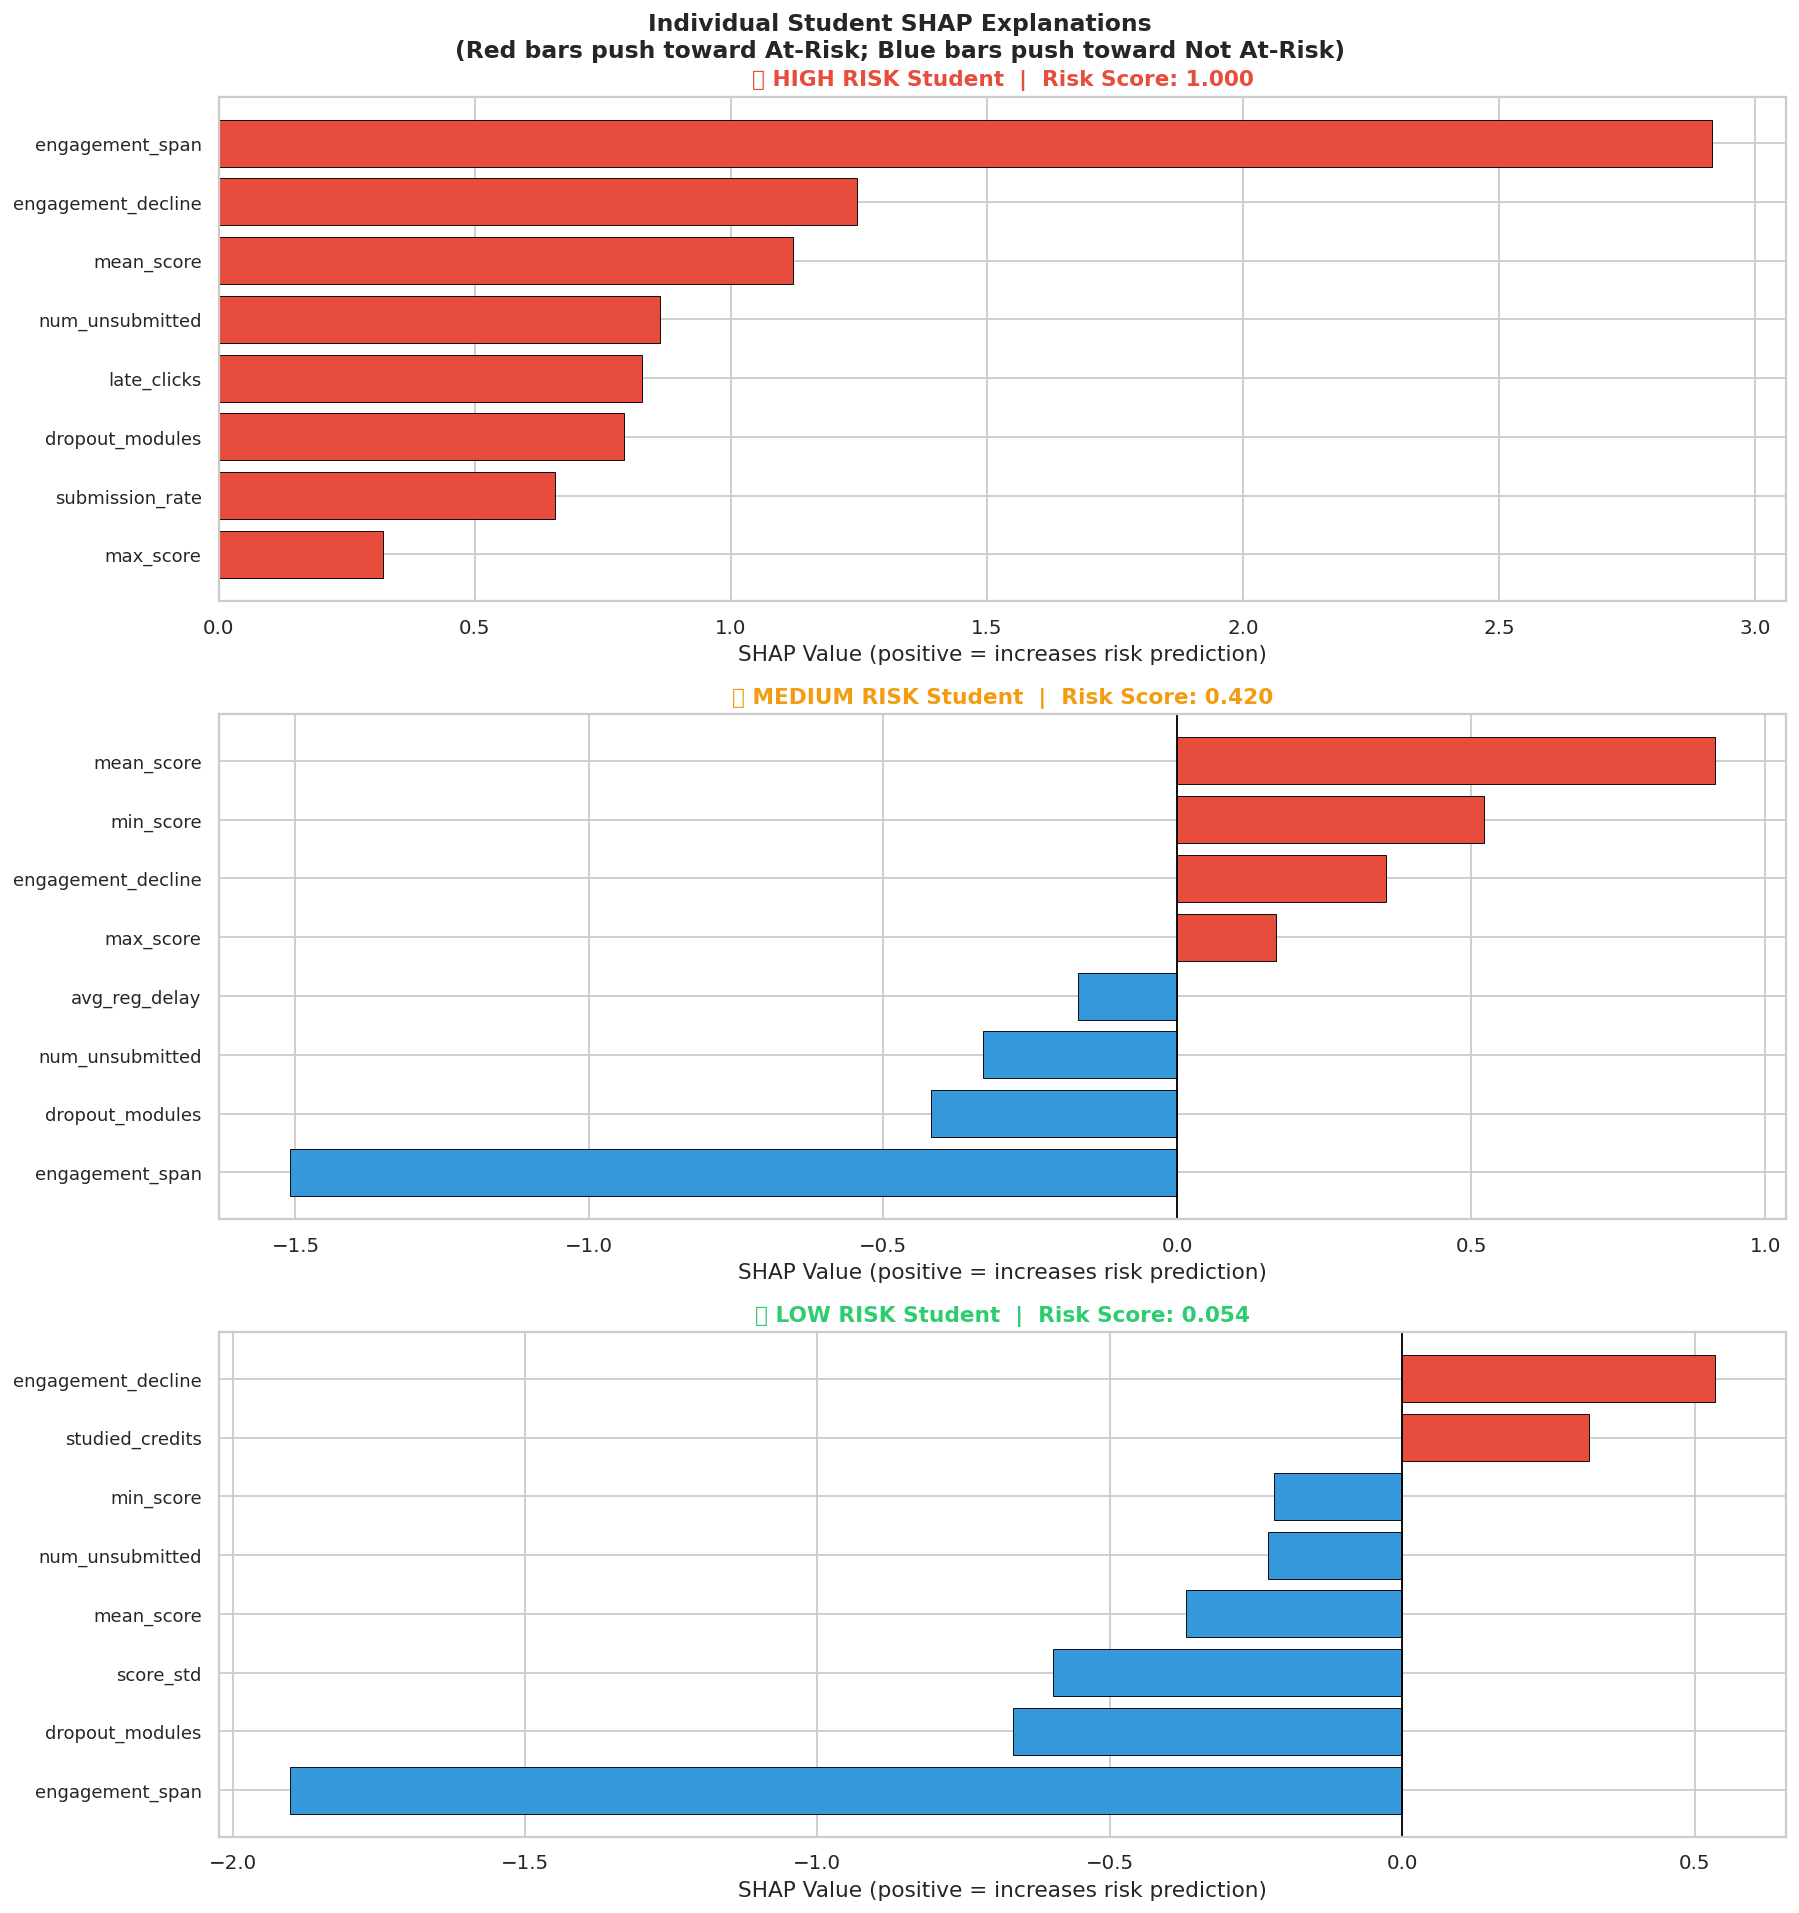

✅ Saved: plot13_shap_individual.png


In [ ]:
# Pick 3 example students: one high-risk, one medium, one low-risk
scored_full = scored.copy()
scored_full.index = range(len(scored_full))

high_risk_idx   = scored_full[scored_full['risk_tier'] == 'High'].index[0]
medium_risk_idx = scored_full[scored_full['risk_tier'] == 'Medium'].index[0]
low_risk_idx    = scored_full[scored_full['risk_tier'] == 'Low'].index[0]

fig, axes = plt.subplots(3, 1, figsize=(14, 15))
fig.suptitle("Individual Student SHAP Explanations\n"
             "(Red bars push toward At-Risk; Blue bars push toward Not At-Risk)",
             fontsize=13, fontweight='bold')

examples = [
    (high_risk_idx,   "🔴 HIGH RISK Student",   '#e74c3c'),
    (medium_risk_idx, "🟡 MEDIUM RISK Student", '#f39c12'),
    (low_risk_idx,    "🟢 LOW RISK Student",    '#2ecc71'),
]

for ax, (idx, label, color) in zip(axes, examples):
    shap_vals_student = shap_values[idx]
    feat_vals_student = X_full_sc[idx]

    # Get top 8 features by absolute SHAP for this student
    student_shap = pd.Series(shap_vals_student, index=FEATURES)
    top8 = student_shap.abs().sort_values(ascending=False).head(8).index
    plot_shap = student_shap[top8].sort_values()

    bar_colors = ['#e74c3c' if v > 0 else '#3498db' for v in plot_shap.values]
    bars = ax.barh(range(len(plot_shap)), plot_shap.values,
                   color=bar_colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(plot_shap)))
    ax.set_yticklabels(plot_shap.index, fontsize=10)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f"{label}  |  Risk Score: {scored_full.iloc[idx]['risk_score']:.3f}",
                 fontweight='bold', color=color, fontsize=12)
    ax.set_xlabel("SHAP Value (positive = increases risk prediction)")

plt.tight_layout()
plt.savefig('/content/plot13_shap_individual.png', bbox_inches='tight')
plt.show()
print("✅ Saved: plot13_shap_individual.png")

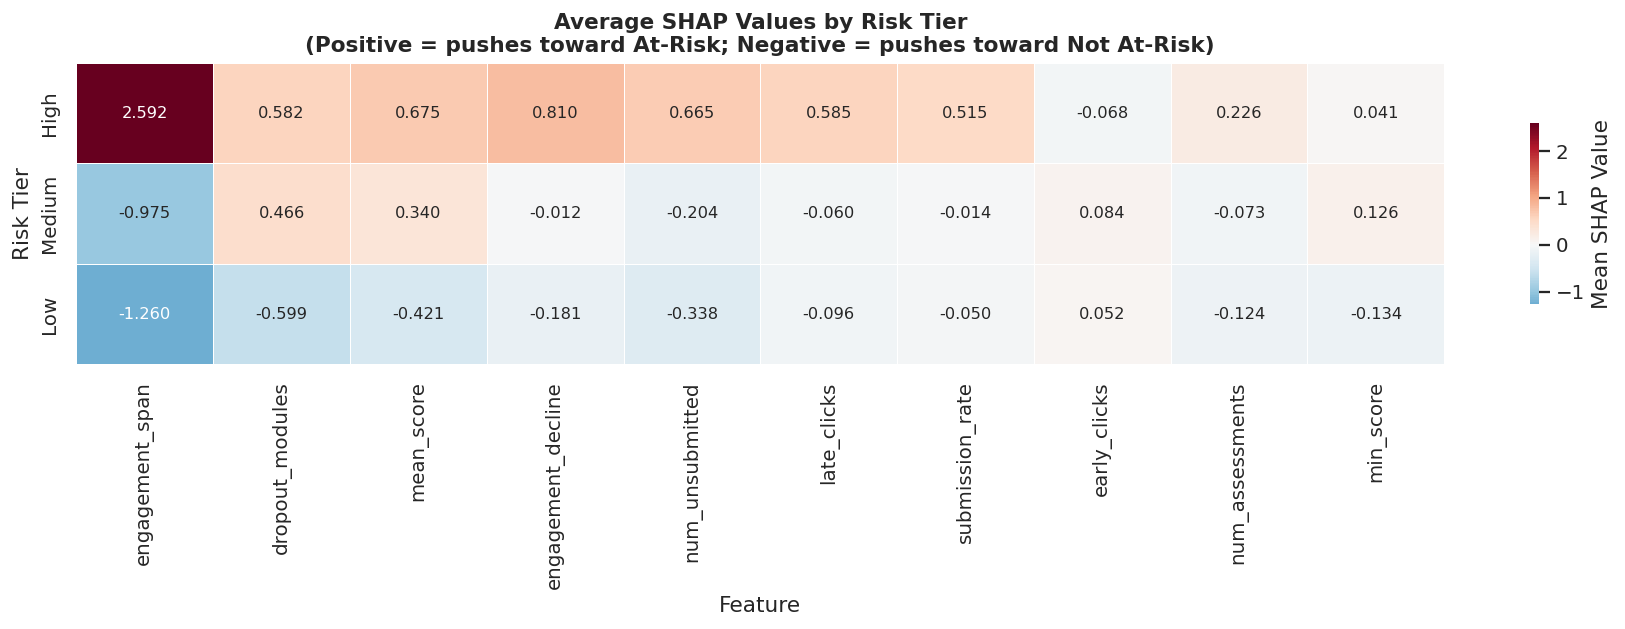

✅ Saved: plot14_shap_tier_heatmap.png


In [ ]:
# Average SHAP values per risk tier — shows WHAT drives each group
scored_full['shap_engagement_span']   = shap_df['engagement_span'].values
scored_full['shap_dropout_modules']   = shap_df['dropout_modules'].values
scored_full['shap_mean_score']        = shap_df['mean_score'].values
scored_full['shap_active_days']       = shap_df['active_days'].values
scored_full['shap_engagement_decline']= shap_df['engagement_decline'].values

top_feats = mean_abs_shap.head(10).index.tolist()
tier_shap = pd.DataFrame()
for feat in top_feats:
    tier_shap[feat] = shap_df[feat].values

tier_shap['risk_tier'] = scored_full['risk_tier'].values
tier_avg = tier_shap.groupby('risk_tier')[top_feats].mean()

# Reorder
tier_order = ['High', 'Medium', 'Low']
tier_avg = tier_avg.reindex([t for t in tier_order if t in tier_avg.index])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(tier_avg, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5,
            cbar_kws={"shrink": 0.6, "label": "Mean SHAP Value"},
            annot_kws={'size': 9})
ax.set_title("Average SHAP Values by Risk Tier\n"
             "(Positive = pushes toward At-Risk; Negative = pushes toward Not At-Risk)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Feature")
ax.set_ylabel("Risk Tier")
plt.tight_layout()
plt.savefig('/content/plot14_shap_tier_heatmap.png', bbox_inches='tight')
plt.show()
print("✅ Saved: plot14_shap_tier_heatmap.png")

In [ ]:
# ── CELL 9: Save SHAP Values (FINAL FIX) ─────────────────────

# Step 1: Reload clean master (always 32,593 rows)
master_orig = pd.read_csv(DATA / "master_dataset.csv").reset_index(drop=True)

# Step 2: Deduplicate scored — keep highest risk score per student
#         (THIS is what was expanding explanation_df to 40,801)
scored_dedup = (scored
                .sort_values('risk_score', ascending=False)
                .drop_duplicates(subset='id_student', keep='first')
                .reset_index(drop=True))

print(f"shap_df rows      : {len(shap_df):,}")
print(f"master_orig rows  : {len(master_orig):,}")
print(f"scored rows       : {len(scored):,}  → after dedup: {len(scored_dedup):,}")

assert len(shap_df) == len(master_orig), \
    f"shap/master mismatch: {len(shap_df)} vs {len(master_orig)}"

# Step 3: Build explanation_df from master_orig (no merge expansion)
explanation_df = master_orig[['id_student', 'code_module', 'is_at_risk']].copy()
explanation_df = explanation_df.merge(
    scored_dedup[['id_student', 'risk_score', 'risk_tier', 'predicted_risk']],
    on='id_student', how='left'
)

print(f"explanation_df rows: {len(explanation_df):,}  ← must equal {len(shap_df):,}")
assert len(explanation_df) == len(shap_df), \
    f"Still expanding: explanation_df={len(explanation_df)}, shap_df={len(shap_df)}"

# Step 4: Assign SHAP reasons by position (safe — all aligned now)
shap_abs = shap_df.abs().reset_index(drop=True)
explanation_df = explanation_df.reset_index(drop=True)

explanation_df['top_reason'] = shap_abs.idxmax(axis=1).values
explanation_df['top_shap']   = shap_abs.max(axis=1).values
explanation_df['reason_2']   = shap_abs.apply(
    lambda r: r.nlargest(2).index[-1], axis=1
).values
explanation_df['reason_3']   = shap_abs.apply(
    lambda r: r.nlargest(3).index[-1], axis=1
).values

# Step 5: Add feature values for dashboard display
for feat in ['engagement_span', 'dropout_modules', 'mean_score',
             'active_days', 'engagement_decline', 'submission_rate']:
    if feat in master_orig.columns:
        explanation_df[feat] = master_orig[feat].values

# Step 6: Save both files
shap_df.to_csv(DATA / "shap_values.csv", index=False)
explanation_df.to_csv(DATA / "student_explanations.csv", index=False)

print(f"\n✅ Saved: shap_values.csv            ({len(shap_df):,} rows)")
print(f"✅ Saved: student_explanations.csv   ({len(explanation_df):,} students)")
print(f"\n   Sample:")
print(explanation_df[['id_student','risk_score','risk_tier',
                       'top_reason','reason_2','reason_3']].head(5).to_string(index=False))

shap_df rows      : 32,593
master_orig rows  : 32,593
scored rows       : 32,593  → after dedup: 28,785
explanation_df rows: 32,593  ← must equal 32,593

✅ Saved: shap_values.csv            (32,593 rows)
✅ Saved: student_explanations.csv   (32,593 students)

   Sample:
 id_student  risk_score risk_tier      top_reason           reason_2   reason_3
      11391    0.053943       Low engagement_span    dropout_modules  score_std
      28400    0.087176       Low engagement_span    dropout_modules mean_score
      30268    0.999897      High engagement_span engagement_decline mean_score
      31604    0.020399       Low engagement_span    dropout_modules  score_std
      32885    0.420246    Medium engagement_span         mean_score  min_score


In [ ]:
!pip install streamlit pyngrok -q

# Upload dashboard.py to /content first
# (download it from the files panel, then upload via Colab files sidebar)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 33.7 MB/s eta 0:00:00


In [ ]:
import subprocess, threading, time
from pyngrok import ngrok

# Paste your token here
!ngrok authtoken 3Cwx778PgUm3CmiQEH6kyTJZtbz_4rxZf5jCKY7N2mY9h8hwa

def run_streamlit():
    subprocess.run([
        "streamlit", "run", "/content/dashboard.py",
        "--server.port", "8501",
        "--server.headless", "true",
        "--server.enableCORS", "false",
        "--server.enableXsrfProtection", "false",
    ])

thread = threading.Thread(target=run_streamlit, daemon=True)
thread.start()
time.sleep(5)

public_url = ngrok.connect(8501)
print(f"\n🎓 DASHBOARD LIVE → {public_url}")
print("Keep this cell running!")

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml

🎓 DASHBOARD LIVE → NgrokTunnel: "https://decimeter-helpless-grab.ngrok-free.dev" -> "http://localhost:8501"
Keep this cell running!


In [ ]:
# ── Paste this as a NEW cell in Colab and run it ──────────────

with open('/content/dashboard.py', 'r') as f:
    content = f.read()

# FIX 1: Replace the gender chart (uses old merged_g variable)
content = content.replace(
    """        fig, ax = plt.subplots(figsize=(5, 3))
        merged_g = df.merge(master[['id_student','gender']].drop_duplicates(), on='id_student', how='left')
        merged_g.groupby('gender')['risk_score'].hist(
            bins=20, alpha=0.6, ax=ax,
            color=['#3498db','#e91e63']
        )
        ax.set_xlabel("Risk Score")
        ax.set_title("Risk Score Distribution by Gender", fontweight='bold')
        patches = [mpatches.Patch(color=c, label=l)
                   for c,l in zip(['#3498db','#e91e63'],['M','F'])]
        ax.legend(handles=patches)
        plt.tight_layout()
        st.pyplot(fig)
        plt.close()""",

    """        fig, ax = plt.subplots(figsize=(5, 3))
        for gender_val, color in [('M','#3498db'),('F','#e91e63')]:
            subset = df[df['gender']==gender_val]['risk_score'].dropna()
            if len(subset) > 0:
                ax.hist(subset, bins=20, alpha=0.6, color=color, label=gender_val, density=True)
        ax.set_xlabel("Risk Score")
        ax.set_ylabel("Density")
        ax.set_title("Risk Score Distribution by Gender", fontweight='bold')
        ax.legend()
        plt.tight_layout()
        st.pyplot(fig)
        plt.close()"""
)

# FIX 2: Replace the age band chart (uses old merged_a variable)
content = content.replace(
    """        merged_a = df.merge(master[['id_student','age_band']].drop_duplicates(), on='id_student', how='left')
        age_risk = merged_a.groupby('age_band')['risk_score'].mean().sort_values()""",
    """        age_risk = df.groupby('age_band')['risk_score'].mean().sort_values()"""
)

with open('/content/dashboard.py', 'w') as f:
    f.write(content)

print("✅ Both fixes applied to /content/dashboard.py")
print("\nNext steps:")
print("1. Stop the running launch cell (click the ⏹ stop button on it)")
print("2. Re-run the launch cell")
print("3. Open the new ngrok URL → Fairness page will work")

✅ Both fixes applied to /content/dashboard.py

Next steps:
1. Stop the running launch cell (click the ⏹ stop button on it)
2. Re-run the launch cell
3. Open the new ngrok URL → Fairness page will work


In [ ]:
# ── PASTE THIS AS A NEW CELL AND RUN IT ──────────────────────
import subprocess, threading, time
from pyngrok import ngrok

# Step 1: Kill existing Streamlit and ngrok
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
ngrok.kill()
time.sleep(3)
print("✅ Old session killed")

# Step 2: Relaunch Streamlit
def run_streamlit():
    subprocess.Popen([
        "streamlit", "run", "/content/dashboard.py",
        "--server.port", "8501",
        "--server.headless", "true",
        "--server.enableCORS", "false",
        "--server.enableXsrfProtection", "false",
    ])

run_streamlit()
time.sleep(8)
print("✅ Streamlit relaunched")

# Step 3: New ngrok tunnel
public_url = ngrok.connect(8501)
print(f"\n🎓 NEW DASHBOARD URL → {public_url}")
print("Open this URL → click 'Visit Site' → go to Fairness Analysis page")

✅ Old session killed
✅ Streamlit relaunched

🎓 NEW DASHBOARD URL → NgrokTunnel: "https://decimeter-helpless-grab.ngrok-free.dev" -> "http://localhost:8501"
Open this URL → click 'Visit Site' → go to Fairness Analysis page


In [ ]:
with open('/content/dashboard.py', 'r') as f:
    lines = f.readlines()

# Show lines 763-775 so we can see exactly what needs replacing
for i in range(762, 775):
    print(f"Line {i+1}: {lines[i].rstrip()}")

Line 763:             fig, ax = plt.subplots(figsize=(5, 3))
Line 764:             merged_g = df.copy()
Line 765:             merged_g.groupby('gender')['risk_score'].hist(
Line 766:                 bins=20, alpha=0.6, ax=ax,
Line 767:                 color=['#3498db','#e91e63']
Line 768:             )
Line 769:             ax.set_xlabel("Risk Score")
Line 770:             ax.set_title("Risk Score Distribution by Gender", fontweight='bold')
Line 771:             patches = [mpatches.Patch(color=c, label=l)
Line 772:                        for c,l in zip(['#3498db','#e91e63'],['M','F'])]
Line 773:             ax.legend(handles=patches)
Line 774:             plt.tight_layout()
Line 775:             st.pyplot(fig)


In [ ]:
with open('/content/dashboard.py', 'r') as f:
    lines = f.readlines()

# Replace lines 763-775 (indices 762 to 774 = 13 lines)
new_block = [
    "            fig, ax = plt.subplots(figsize=(5, 3))\n",
    "            for gv, gc in [('M','#3498db'),('F','#e91e63')]:\n",
    "                s = df[df['gender']==gv]['risk_score'].dropna()\n",
    "                if len(s) > 0:\n",
    "                    ax.hist(s, bins=20, alpha=0.6, color=gc, label=gv, density=True)\n",
    "            ax.set_xlabel('Risk Score')\n",
    "            ax.set_ylabel('Density')\n",
    "            ax.set_title('Risk Score by Gender', fontweight='bold')\n",
    "            ax.legend()\n",
    "            plt.tight_layout()\n",
    "            st.pyplot(fig)\n",
    "            plt.close()\n",
]

lines[762:775] = new_block  # replace exactly 13 lines

with open('/content/dashboard.py', 'w') as f:
    f.writelines(lines)

print("✅ Fixed! New lines 763 onwards:")
with open('/content/dashboard.py', 'r') as f:
    verify = f.readlines()
for i in range(761, 776):
    print(f"  {i+1}: {verify[i].rstrip()}")

✅ Fixed! New lines 763 onwards:
  762:             st.dataframe(gdf, use_container_width=True)
  763:             fig, ax = plt.subplots(figsize=(5, 3))
  764:             for gv, gc in [('M','#3498db'),('F','#e91e63')]:
  765:                 s = df[df['gender']==gv]['risk_score'].dropna()
  766:                 if len(s) > 0:
  767:                     ax.hist(s, bins=20, alpha=0.6, color=gc, label=gv, density=True)
  768:             ax.set_xlabel('Risk Score')
  769:             ax.set_ylabel('Density')
  770:             ax.set_title('Risk Score by Gender', fontweight='bold')
  771:             ax.legend()
  772:             plt.tight_layout()
  773:             st.pyplot(fig)
  774:             plt.close()
  775:     with col2:
  776:         st.subheader("By Age Band")


In [ ]:
with open('/content/dashboard.py', 'r') as f:
    lines = f.readlines()

# Find and fix EVERY line that still mentions merged_a or merged_g
fixed = 0
for i, line in enumerate(lines):
    if 'merged_a.groupby' in line:
        lines[i] = line.replace('merged_a.groupby', 'df.groupby')
        print(f"✅ Fixed line {i+1}: {lines[i].rstrip()}")
        fixed += 1
    if 'merged_g.groupby' in line:
        lines[i] = line.replace('merged_g.groupby', 'df.groupby')
        print(f"✅ Fixed line {i+1}: {lines[i].rstrip()}")
        fixed += 1

with open('/content/dashboard.py', 'w') as f:
    f.writelines(lines)

print(f"\n✅ Total fixes applied: {fixed}")

✅ Fixed line 781:             age_risk = df.groupby('age_band')['risk_score'].mean().sort_values()

✅ Total fixes applied: 1


In [ ]:
import subprocess, time
from pyngrok import ngrok

subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
ngrok.kill()
time.sleep(3)
subprocess.Popen(["streamlit", "run", "/content/dashboard.py",
    "--server.port", "8501", "--server.headless", "true",
    "--server.enableCORS", "false", "--server.enableXsrfProtection", "false"])
time.sleep(8)
public_url = ngrok.connect(8501)
print(f"\n🎓 NEW URL → {public_url}")


🎓 NEW URL → NgrokTunnel: "https://decimeter-helpless-grab.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
import shutil, os
from pathlib import Path

# ── Your permanent Drive folder ──────────────────────────────
DRIVE = Path("/content/drive/MyDrive/Capstone_MentalHealth")
for folder in ['data', 'models', 'plots', 'code']:
    (DRIVE / folder).mkdir(parents=True, exist_ok=True)

saved = []

# Save all CSVs
for f in Path("/content/data").glob("*.csv"):
    shutil.copy2(f, DRIVE / "data" / f.name)
    saved.append(f"data/{f.name}")

# Save all models
for f in Path("/content/models").glob("*.pkl"):
    shutil.copy2(f, DRIVE / "models" / f.name)
    saved.append(f"models/{f.name}")

# Save all plots
for f in Path("/content").glob("plot*.png"):
    shutil.copy2(f, DRIVE / "plots" / f.name)
    saved.append(f"plots/{f.name}")

# Save all Python scripts
for f in Path("/content").glob("*.py"):
    shutil.copy2(f, DRIVE / "code" / f.name)
    saved.append(f"code/{f.name}")

print("✅ SAVED TO GOOGLE DRIVE:")
for item in sorted(saved):
    print(f"   📄 {item}")
print(f"\n📁 Location: {DRIVE}")
print(f"   Total files saved: {len(saved)}")

✅ SAVED TO GOOGLE DRIVE:
   📄 code/dashboard.py
   📄 data/assessments.csv
   📄 data/courses.csv
   📄 data/master_dataset.csv
   📄 data/scored_students.csv
   📄 data/shap_values.csv
   📄 data/studentAssessment.csv
   📄 data/studentInfo.csv
   📄 data/studentRegistration.csv
   📄 data/studentVle.csv
   📄 data/student_explanations.csv
   📄 data/vle.csv
   📄 models/lr_model.pkl
   📄 models/rf_model.pkl
   📄 models/scaler.pkl
   📄 models/xgb_model.pkl
   📄 plots/plot10_shap_summary.png
   📄 plots/plot11_shap_bar.png
   📄 plots/plot12_shap_dependence.png
   📄 plots/plot13_shap_individual.png
   📄 plots/plot14_shap_tier_heatmap.png
   📄 plots/plot1_outcomes_demographics.png
   📄 plots/plot2_registration_patterns.png
   📄 plots/plot3_behavioral_signals.png
   📄 plots/plot4_correlation_heatmap.png
   📄 plots/plot5_roc_pr_curves.png
   📄 plots/plot6_confusion_matrices.png
   📄 plots/plot7_feature_importance.png
   📄 plots/plot8_model_comparison.png
   📄 plots/plot9_risk_score_distribution.png

📁 